# AllLifeBank Customer Segmentation

## Description:
### Context:
AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalised campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customers queries are resolved faster. Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help
Objective: To identify different segments in the existing customer based on their spending patterns as well as past interaction with the bank.

#### Data Description:
Data is of various customers of a bank with their credit limit, the total number of credit cards the customer has, and different channels through which customer has contacted the bank for any queries, different channels include visiting the bank, online and through a call centre.


In [ ]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from sklearn import metrics

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage,cophenet
from sklearn.cluster import AgglomerativeClustering




In [ ]:
data= pd.read_excel(r'/content/Credit Card Customer Data.xlsx')

In [ ]:
CreditCardData=data.copy()

In [ ]:
CreditCardData.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
CreditCardData.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [ ]:
CreditCardData.shape
print(f'Dataset has {CreditCardData.shape[0]} rows and {CreditCardData.shape[1]} columns.')  # f-string


Dataset has 660 rows and 7 columns.


In [ ]:
CreditCardData.info()
CreditCardData.columns = CreditCardData.columns.str.replace(' ', '_')
#count the number of variables in each datatype
CreditCardData.dtypes.value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


,count
int64,7


In [ ]:
sum(CreditCardData.duplicated())


0

Summary of the dataset

In [ ]:
CreditCardData.describe(include="all")
# checking for unique values in Customer Key column
CreditCardData["Customer_Key"].nunique()

655


There are 660 records in the dataset and 655 unique customer key records.So, there must be 5 dupliacte records.

In [ ]:
CreditCardData["Customer_Key"].duplicated().sum()


5

In [ ]:
CreditCardData.loc[CreditCardData["Customer_Key"].duplicated(keep=False), :].sort_values(by="Customer_Key", ascending=False)


,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
4,5,47437,100000,6,0,12,3
332,333,47437,17000,7,3,1,0
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2


In [ ]:
CreditCardData = CreditCardData[(~CreditCardData["Customer_Key"].duplicated())].copy()


In [ ]:
CreditCardData.shape
CreditCardData["Sl_No"].nunique()
CreditCardData.drop(["Sl_No"],axis=1,inplace=True)
CreditCardData["Customer_Key"].nunique()
CreditCardData["Customer_Key"].duplicated().sum()


0

In [ ]:
CreditCardData.head()


,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,87073,100000,2,1,1,0
1,38414,50000,3,0,10,9
2,17341,50000,7,1,3,4
3,40496,30000,5,1,1,4
4,47437,100000,6,0,12,3


In [ ]:
CreditCardData[(CreditCardData.Total_visits_online == 0)].iloc[:,1:].describe().T


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,144.0,35131.944444,22971.324943,5000.0,13750.0,35000.0,56000.0,75000.0
Total_Credit_Cards,144.0,5.534722,1.211329,4.0,4.0,6.0,7.0,7.0
Total_visits_bank,144.0,3.506944,1.176676,2.0,2.0,3.5,5.0,5.0
Total_visits_online,144.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Total_calls_made,144.0,2.069444,1.475453,0.0,1.0,2.0,3.0,4.0


In [ ]:
CreditCardData[(CreditCardData.Total_visits_bank == 0)].iloc[:,1:].describe().T


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,100.0,39150.00,56004.035749,3000.0,9000.0,14000.0,20000.0,200000.0
Total_Credit_Cards,100.0,3.54,2.698372,1.0,2.0,3.0,4.0,10.0
Total_visits_bank,100.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.0
Total_visits_online,100.0,5.03,3.616614,1.0,3.0,4.0,5.0,15.0
Total_calls_made,100.0,5.82,3.085908,0.0,4.0,6.0,8.0,10.0


In [ ]:
CreditCardData[(CreditCardData.Total_calls_made == 0)].iloc[:,1:].describe().T


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,95.0,53536.842105,48632.536724,6000.0,15500.0,41000.0,69500.0,200000.0
Total_Credit_Cards,95.0,5.957895,1.719202,2.0,4.5,6.0,7.0,10.0
Total_visits_bank,95.0,3.010526,1.512323,0.0,2.0,3.0,4.0,5.0
Total_visits_online,95.0,2.557895,4.109449,0.0,0.0,1.0,2.0,15.0
Total_calls_made,95.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
CreditCardData.Total_visits_online.sum()
CreditCardData.Total_visits_bank.sum()
CreditCardData.Total_calls_made.sum()


2359

Univariate analysis

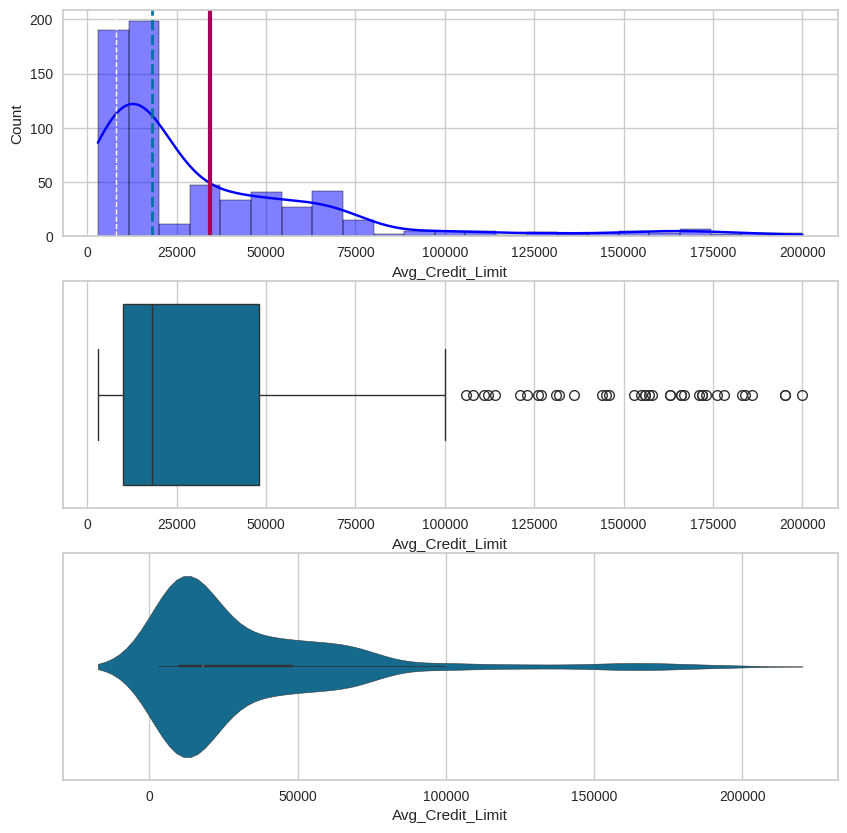

In [ ]:
#View the distribution of the Avg_Credit_Limit variable
plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
sns.histplot(x=CreditCardData.Avg_Credit_Limit,color="blue",kde=True);
plt.axvline(CreditCardData["Avg_Credit_Limit"].mean(),color='m',linewidth=3)# draw a line indicating mean
plt.axvline(CreditCardData["Avg_Credit_Limit"].median(),color='b',linestyle='dashed',linewidth=2)# draw a line indicating median
plt.axvline(CreditCardData["Avg_Credit_Limit"].mode()[0],color='w',linestyle='dashed',linewidth=1)# draw a line indicating mode
plt.subplot(3,1,2)
sns.boxplot(x=CreditCardData.Avg_Credit_Limit);
plt.subplot(3,1,3)
sns.violinplot(x=CreditCardData.Avg_Credit_Limit);

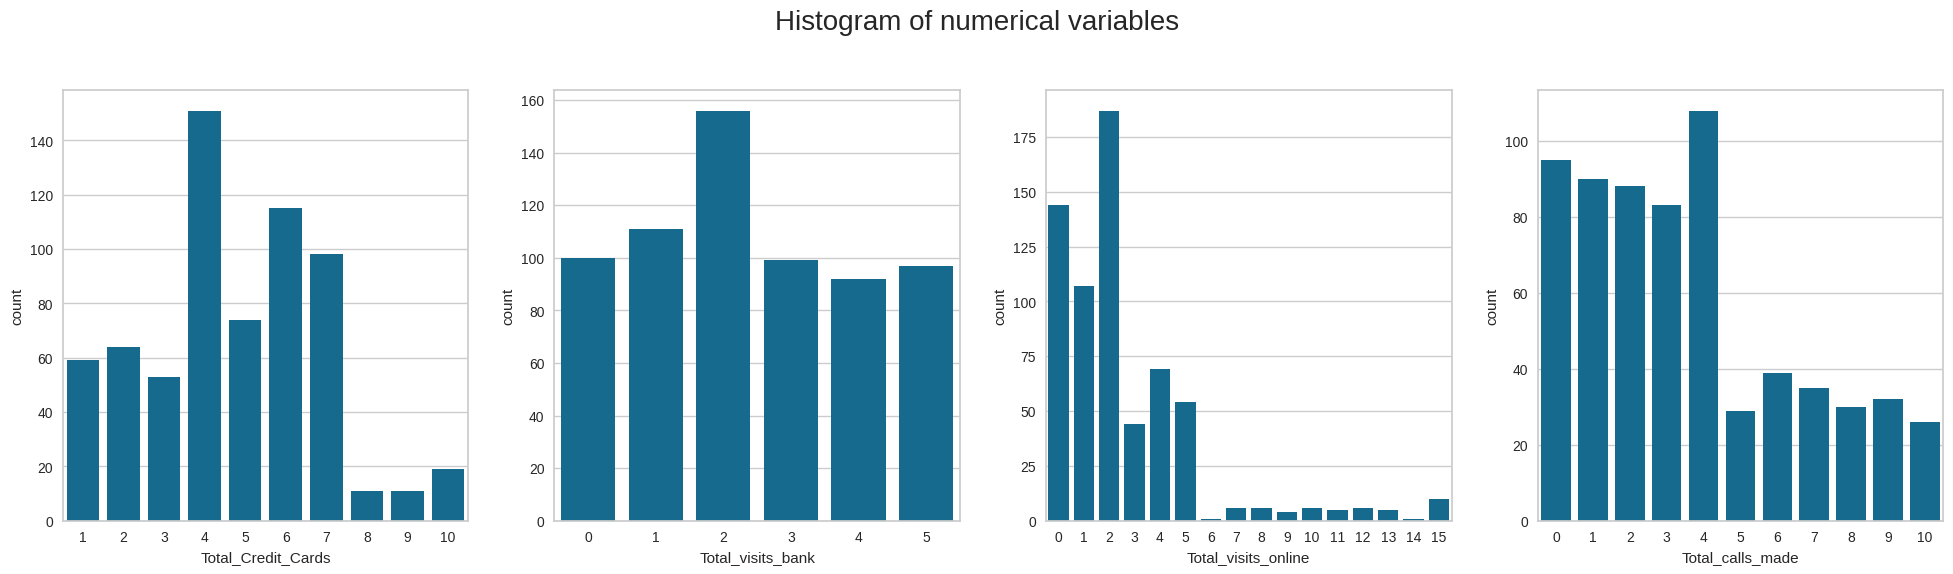

In [ ]:
all_col = CreditCardData.iloc[:,1:].columns.tolist()
all_cat_col = CreditCardData.iloc[:,2:].columns.tolist()
fig, axes = plt.subplots(1, 4,  figsize=(20, 6))
fig.suptitle('Histogram of numerical variables', fontsize=20)
counter = 0
for ii in range(4):
    sns.countplot(ax=axes[ii],x=CreditCardData[all_cat_col[counter]])
    counter = counter+1

fig.tight_layout(pad=2.0)

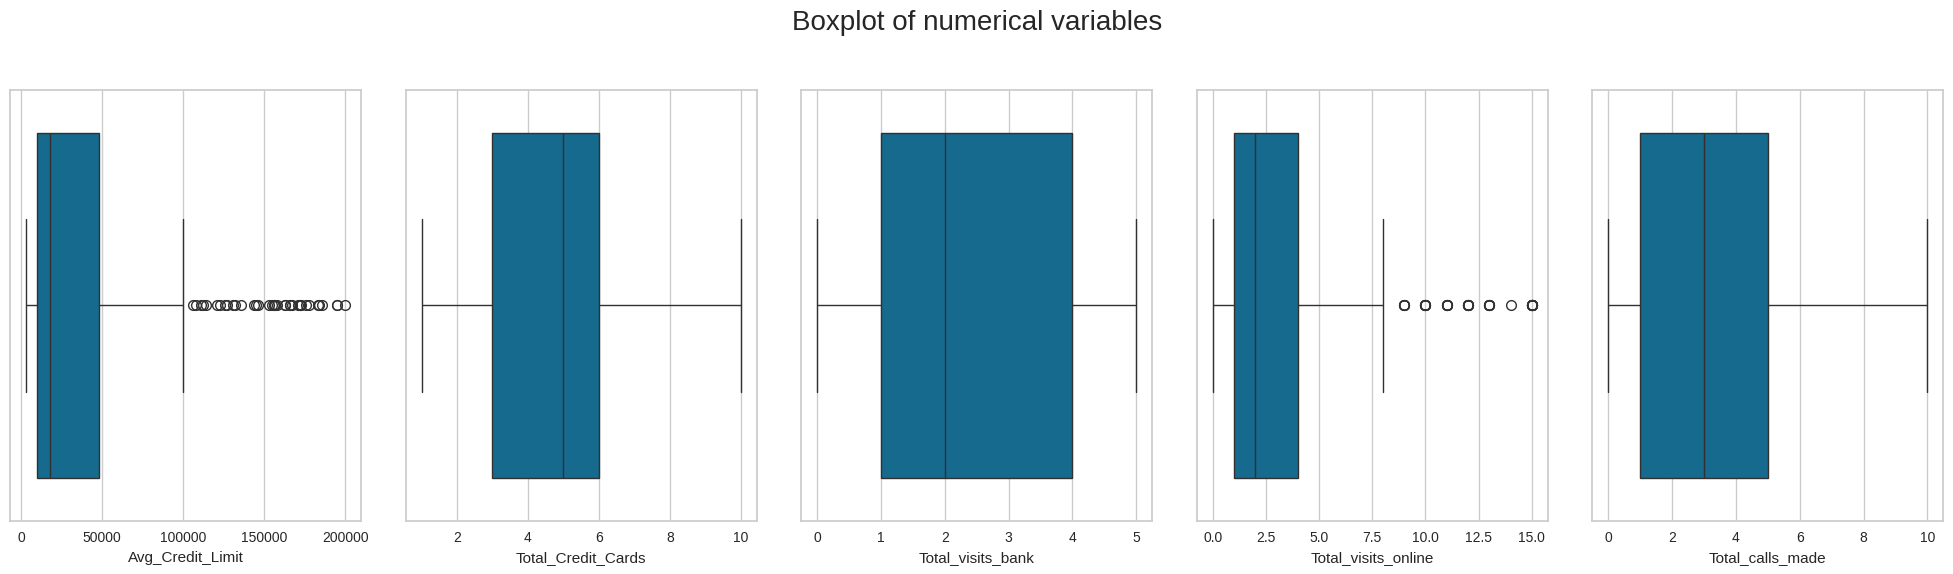

In [ ]:
fig, axes = plt.subplots(1, 5,  figsize=(20, 6))
fig.suptitle('Boxplot of numerical variables', fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],x=CreditCardData[all_col[counter]])
    counter = counter+1

fig.tight_layout(pad=2.0)

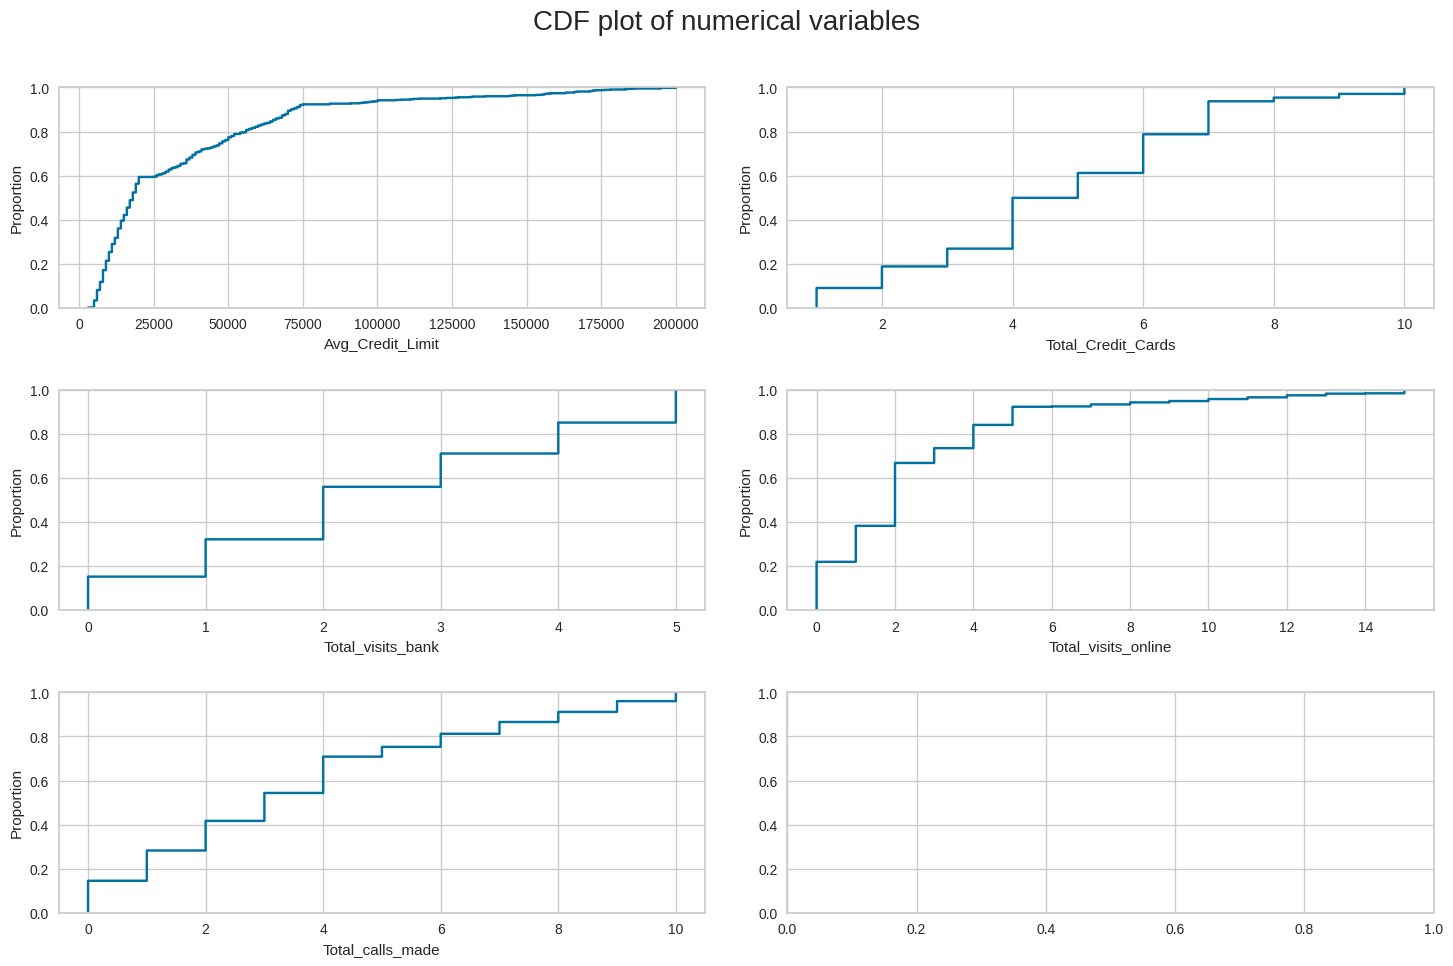

In [ ]:
# select numerical columns

fig, axes = plt.subplots(3, 2,  figsize=(15, 10))
fig.suptitle('CDF plot of numerical variables', fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0],x=CreditCardData[all_col[counter]])
    counter = counter+1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1],x=CreditCardData[all_col[counter]])
        counter = counter+1
    else:
        pass


fig.tight_layout(pad=2.0)

### Bivariate Analsysis

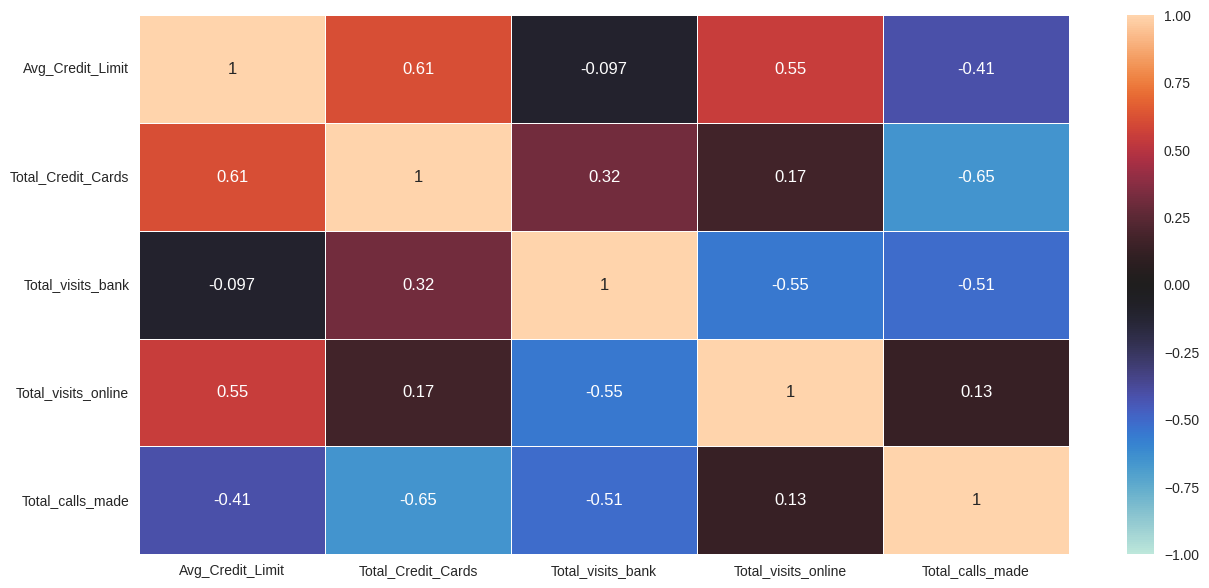

In [ ]:
plt.figure(figsize=(15,7))

sns.heatmap(CreditCardData[all_col].corr(),
            annot=True,
            linewidths=0.5,vmin=-1,vmax=1,
            center=0,
            cbar=True,)

plt.show()

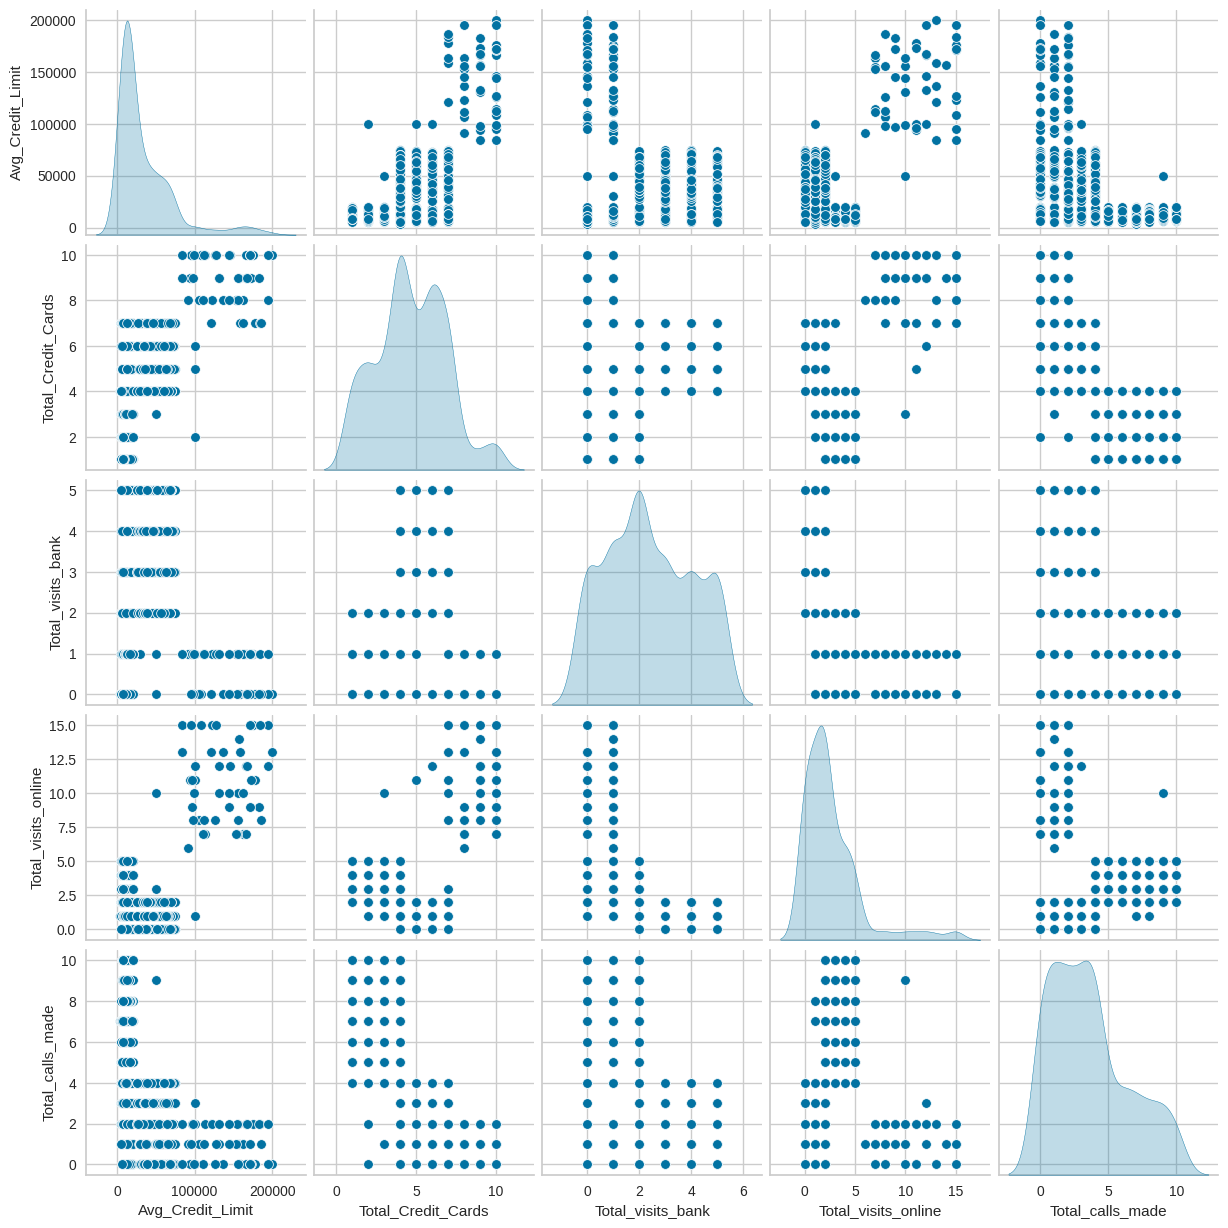

In [ ]:
sns.pairplot(CreditCardData[all_col],diag_kind="kde");


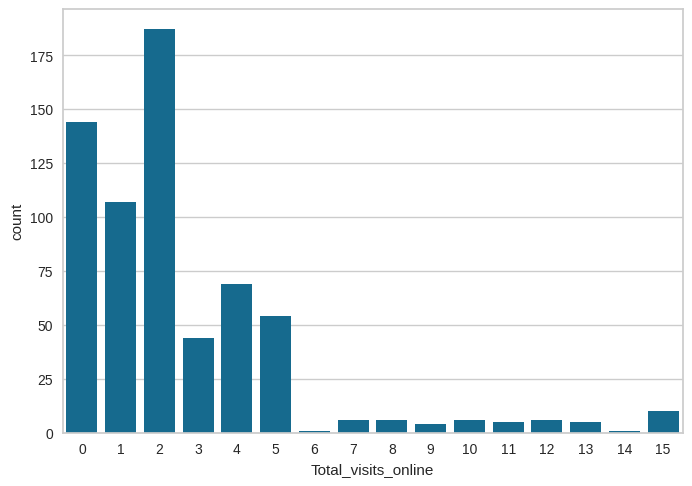

In [ ]:
sns.countplot(x='Total_visits_online',data=CreditCardData);


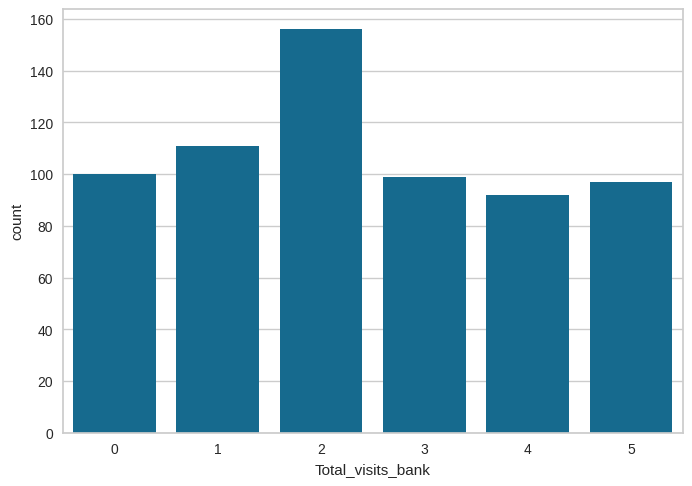

In [ ]:
sns.countplot(x='Total_visits_bank',data=CreditCardData);


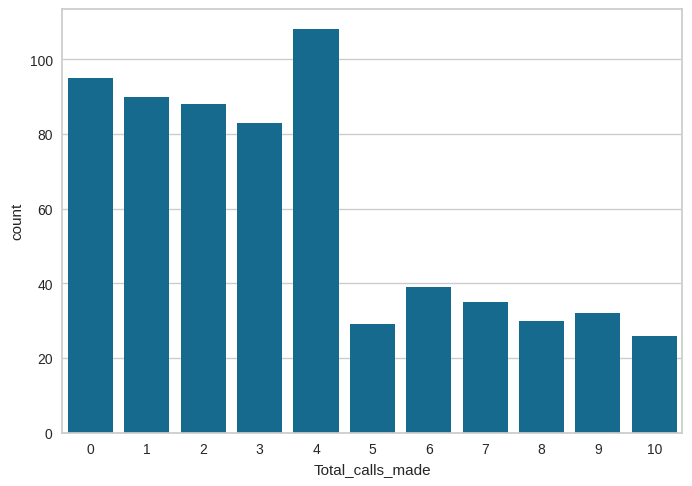

In [ ]:
sns.countplot(x='Total_calls_made',data=CreditCardData);


In [ ]:
CreditCardData.groupby(["Total_Credit_Cards"])['Avg_Credit_Limit'].mean()


,Avg_Credit_Limit
Total_Credit_Cards,
1,11457.627119
2,13187.500000
3,13301.886792
4,26311.258278
5,34689.189189
6,32686.956522
7,43163.265306
8,139454.545455
9,140090.909091


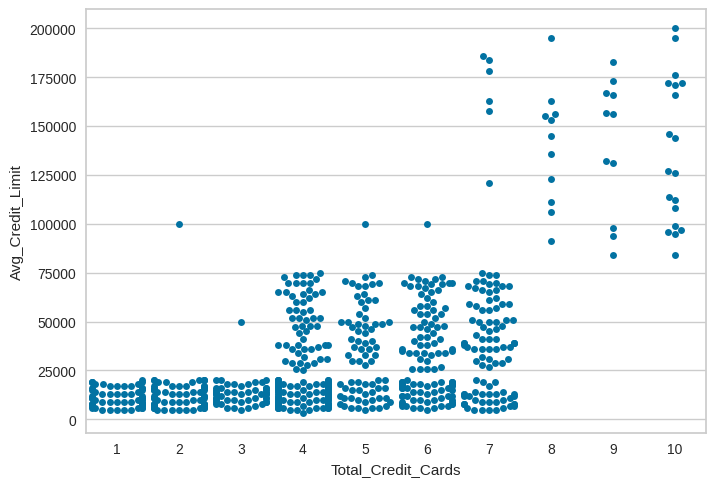

In [ ]:
sns.swarmplot(x='Total_Credit_Cards',y='Avg_Credit_Limit',data=CreditCardData);


In [ ]:
CreditCardData.groupby(["Total_Credit_Cards"])['Total_visits_bank'].mean()


,Total_visits_bank
Total_Credit_Cards,
1,0.932203
2,0.921875
3,0.867925
4,2.768212
5,3.256757
6,3.582609
7,3.214286
8,0.636364
9,0.727273


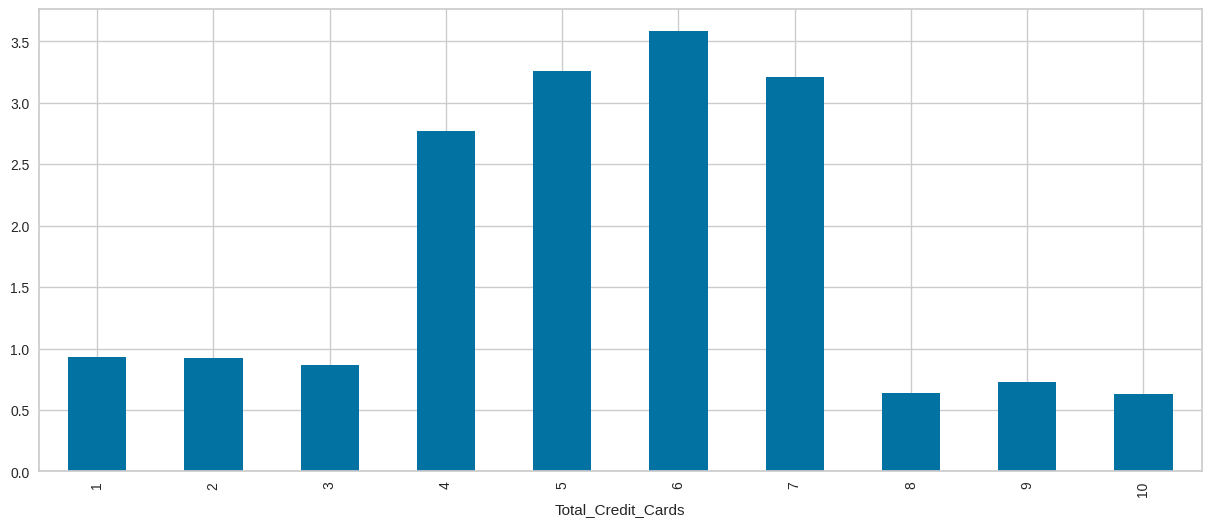

In [ ]:
CreditCardData.groupby(["Total_Credit_Cards"])['Total_visits_bank'].mean().plot.bar(figsize=(15,6));


In [ ]:
CreditCardData.groupby(["Total_Credit_Cards"])['Total_visits_online'].mean()


,Total_visits_online
Total_Credit_Cards,
1,3.491525
2,3.531250
3,3.698113
4,1.728477
5,1.216216
6,1.156522
7,1.530612
8,9.272727
9,11.272727


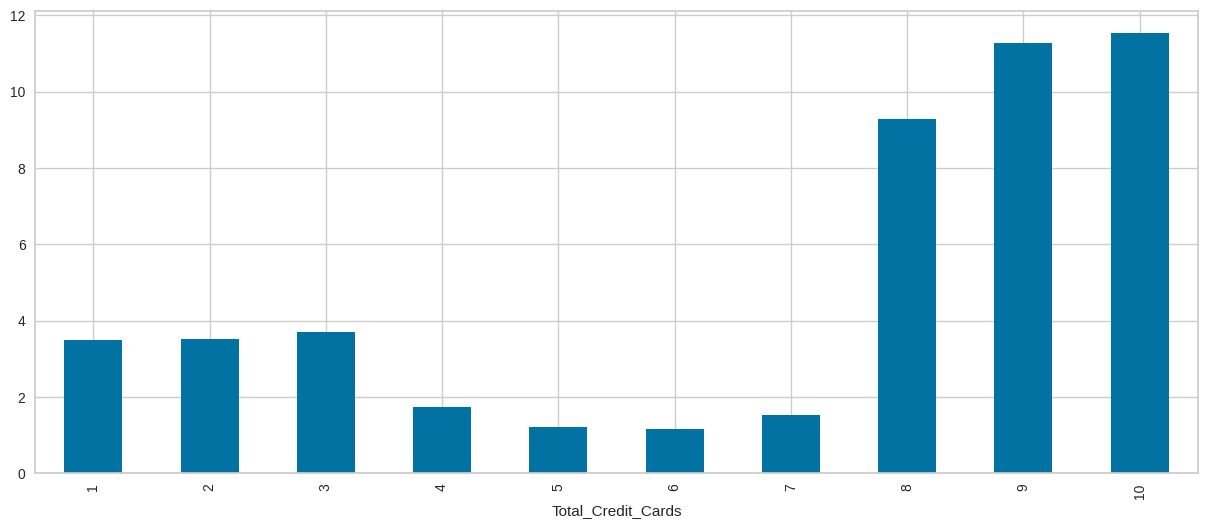

In [ ]:
CreditCardData.groupby(["Total_Credit_Cards"])['Total_visits_online'].mean().plot.bar(figsize=(15,6));


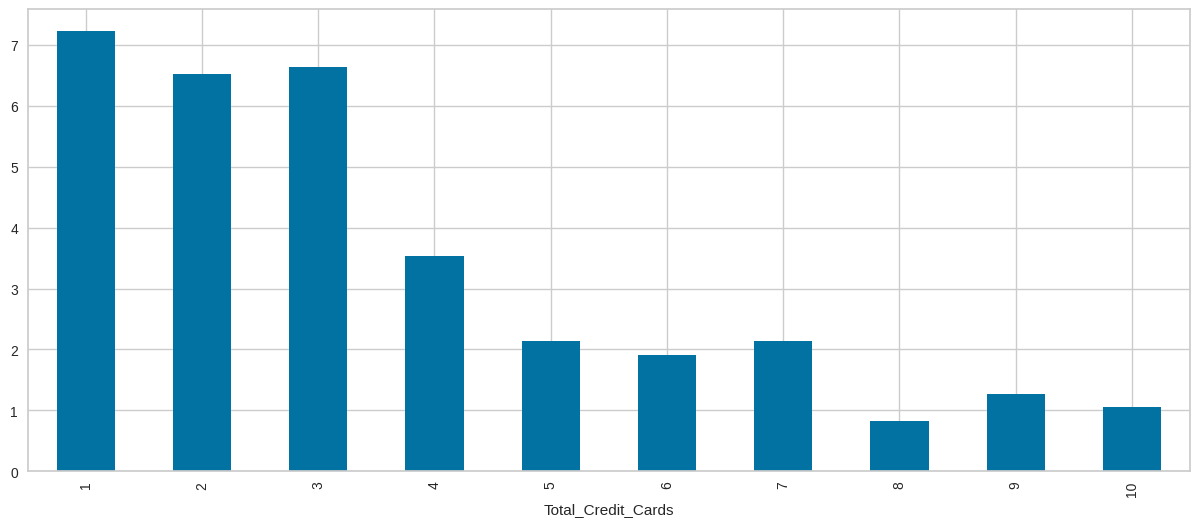

In [ ]:
import matplotlib.pyplot as plt
CreditCardData.groupby(["Total_Credit_Cards"])['Total_calls_made'].mean().plot.bar(figsize=(15,6));

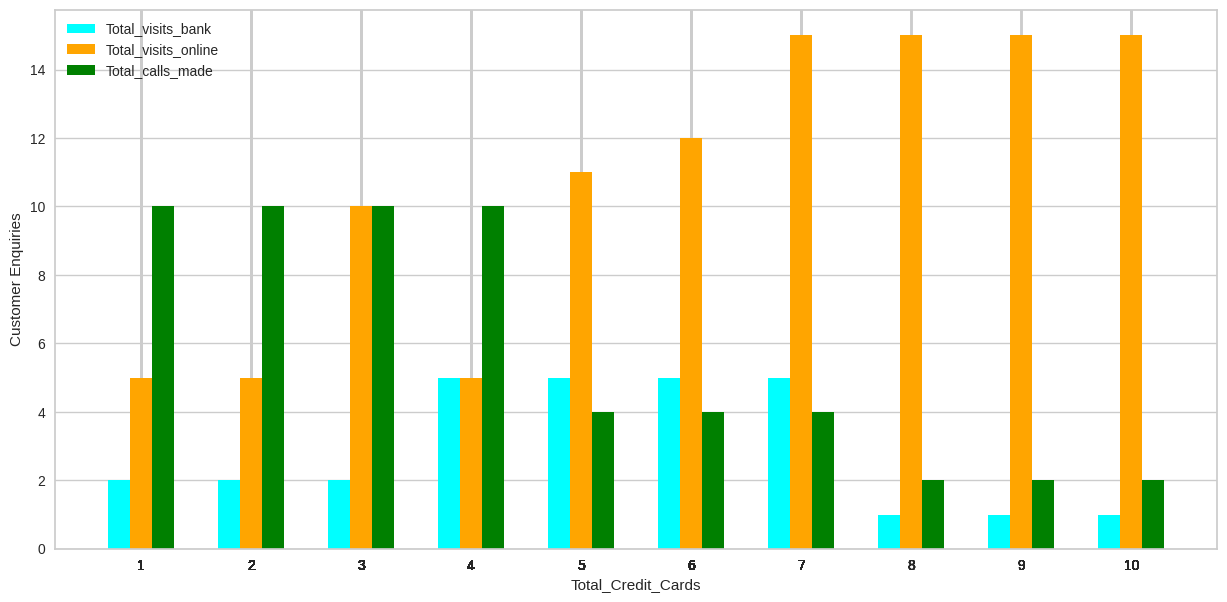

In [ ]:
plt.figure(figsize=(15,7))
width = 0.2
y1=CreditCardData['Total_visits_bank']
y2= CreditCardData['Total_visits_online']
y3=CreditCardData['Total_calls_made']
x = CreditCardData["Total_Credit_Cards"]
# plot data in grouped manner of bar type
plt.bar(x-0.2, y1, width, color='cyan')
plt.bar(x, y2, width, color='orange')
plt.bar(x+0.2, y3, width, color='green')
plt.xticks(x)
plt.xlabel("Total_Credit_Cards")
plt.ylabel("Customer Enquiries")
plt.legend(["Total_visits_bank", "Total_visits_online", "Total_calls_made"])
plt.show()

Treating Outliers

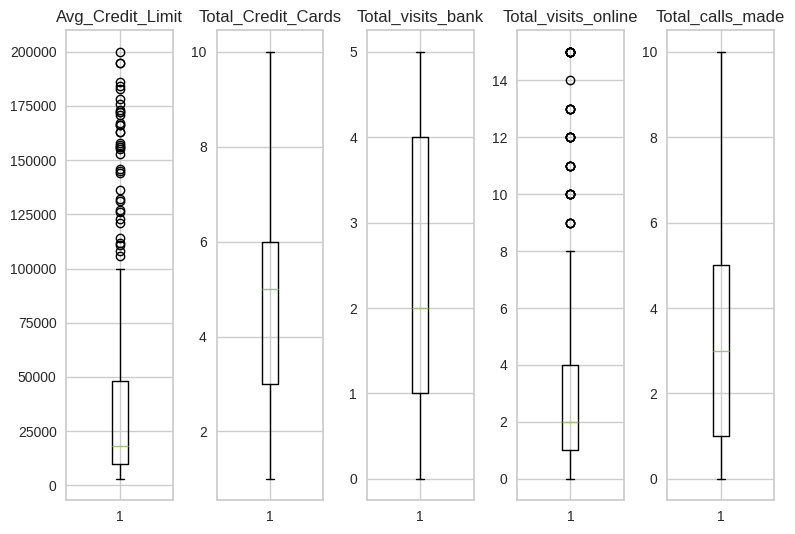

In [ ]:
# lets look at box plot to see the outliers


for i, variable in enumerate(all_col):
                     plt.subplot(1,5,i+1)
                     plt.boxplot(CreditCardData[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)

plt.show()

In [ ]:
# Lets treat outliers by flooring and capping them at 1.5IQR
def treat_outliers(df,col):
    '''
    treats outliers in a varaible
    col: str, name of the numerical varaible
    df: data frame
    col: name of the column
    '''
    Q1=df[col].quantile(0.25) # 25th quantile
    Q3=df[col].quantile(0.75)  # 75th quantile
    IQR=Q3-Q1
    Lower_Whisker = Q1 - 1.5*IQR
    Upper_Whisker = Q3 + 1.5*IQR
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker) # all the values samller than Lower_Whisker will be assigned value of Lower_whisker
                                                            # and all the values above upper_whishker will be assigned value of upper_Whisker
    return df

def treat_outliers_all(df, col_list):
    '''
    treat outlier in all numerical varaibles
    col_list: list of numerical varaibles
    df: data frame
    '''
    for c in col_list:
        df = treat_outliers(df,c)

    return df


In [ ]:
CreditCardData = treat_outliers_all(CreditCardData,['Avg_Credit_Limit'])


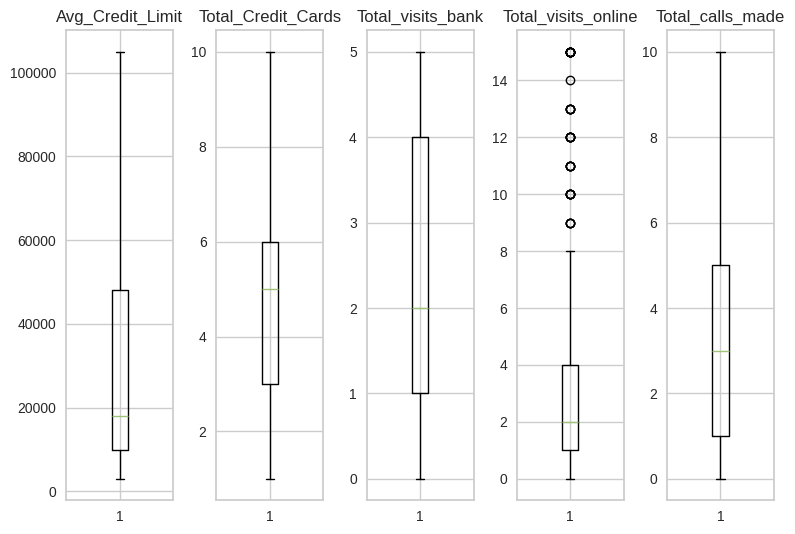

In [ ]:
# lets look at box plot to see if outliers has been treated or not
for i, variable in enumerate(all_col):
                     plt.subplot(1,5,i+1)
                     plt.boxplot(CreditCardData[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)

plt.show()

Scaling the data

In [ ]:
# Scaling the data set before clustering
scaler=StandardScaler()
subset=CreditCardData[all_col].copy()
subset_scaled=scaler.fit_transform(subset)

In [ ]:
#Creating a dataframe from the scaled data above
subset_scaled_df=pd.DataFrame(subset_scaled,columns=subset.columns)

K-Means Clustering

Number of Clusters: 1 	Average Distortion: 2.044353007149102
Number of Clusters: 2 	Average Distortion: 1.4852012536807695
Number of Clusters: 3 	Average Distortion: 1.1818148855916517
Number of Clusters: 4 	Average Distortion: 1.0690604053677273
Number of Clusters: 5 	Average Distortion: 1.0121768661912451
Number of Clusters: 6 	Average Distortion: 0.9983753359655906
Number of Clusters: 7 	Average Distortion: 0.923573344056418
Number of Clusters: 8 	Average Distortion: 0.898988622058406


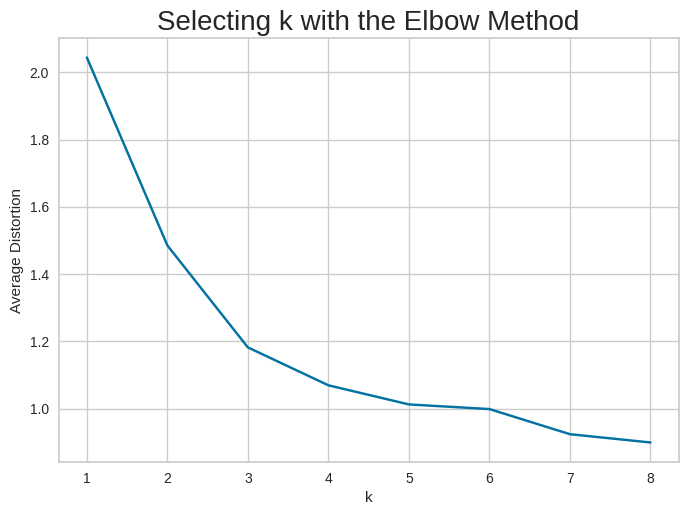

In [ ]:
clusters=range(1,9)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction=model.predict(subset_scaled_df)
    distortion=sum(np.min(cdist(subset_scaled_df, model.cluster_centers_, 'euclidean'), axis=1)) / subset_scaled_df.shape[0]

    meanDistortions.append(distortion)

    print('Number of Clusters:', k, '\tAverage Distortion:', distortion)

plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average Distortion')
plt.title('Selecting k with the Elbow Method', fontsize=20);


From Elbow method, 3 can be a good value for K

Lets us check silhoutte score

In [ ]:
sil_score = []
cluster_list = list(range(2,10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    #centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.41388548264460095)
For n_clusters = 3, silhouette score is 0.5075035671327102)
For n_clusters = 4, silhouette score is 0.37994779554254654)
For n_clusters = 5, silhouette score is 0.35001417185967926)
For n_clusters = 6, silhouette score is 0.3379528908710422)
For n_clusters = 7, silhouette score is 0.2681766077122466)
For n_clusters = 8, silhouette score is 0.2460589532096732)
For n_clusters = 9, silhouette score is 0.22448775656166595)


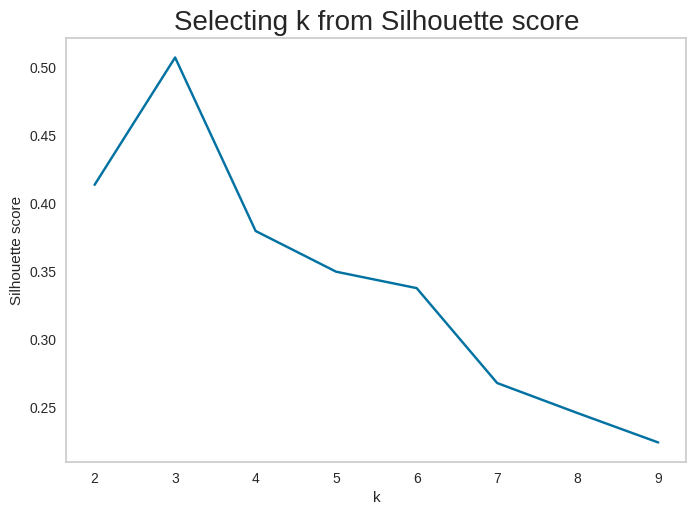

In [ ]:
plt.plot(cluster_list,sil_score)
plt.grid()
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Selecting k from Silhouette score', fontsize=20);

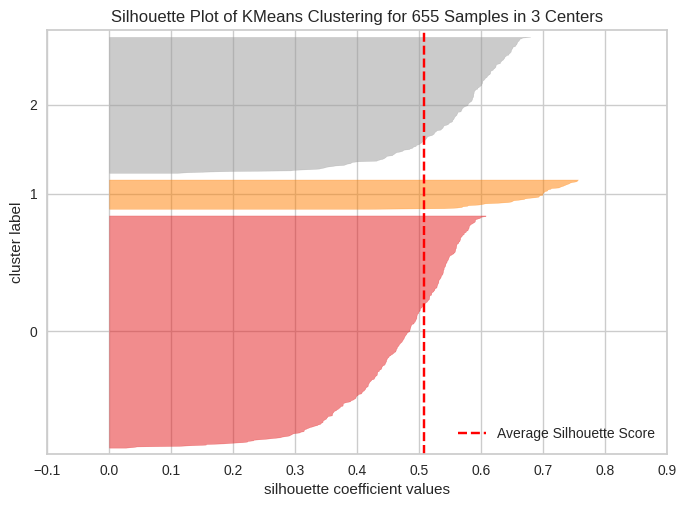

In [ ]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state = 1))
visualizer.fit(subset_scaled_df)
visualizer.show();

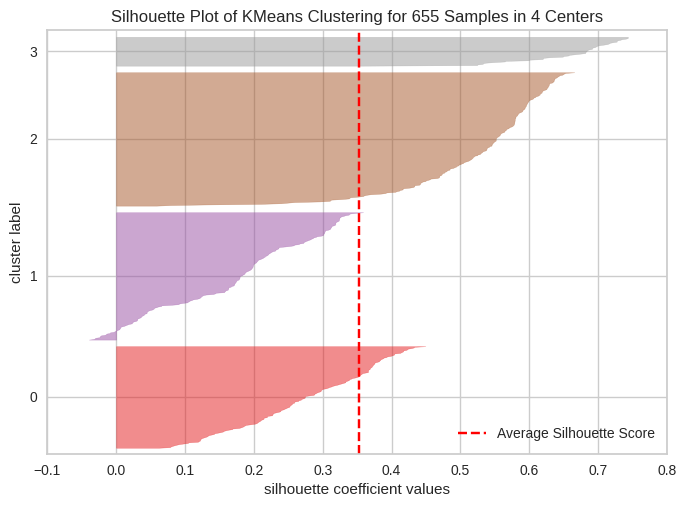

In [ ]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state = 1))
visualizer.fit(subset_scaled_df)
visualizer.show();

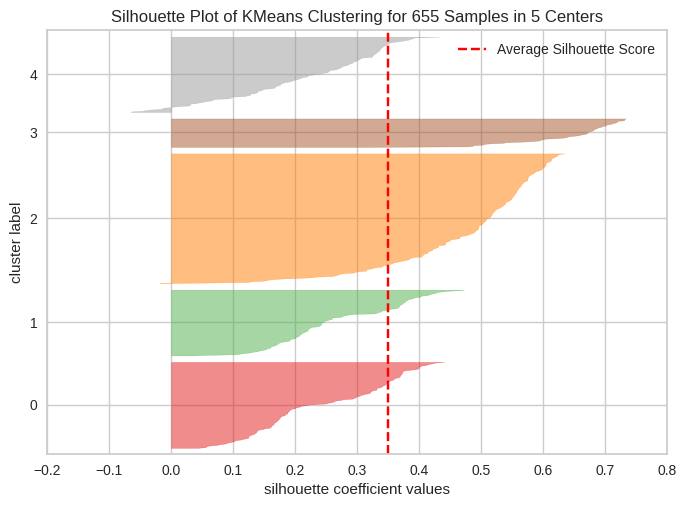

In [ ]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state = 1))
visualizer.fit(subset_scaled_df)
visualizer.show();

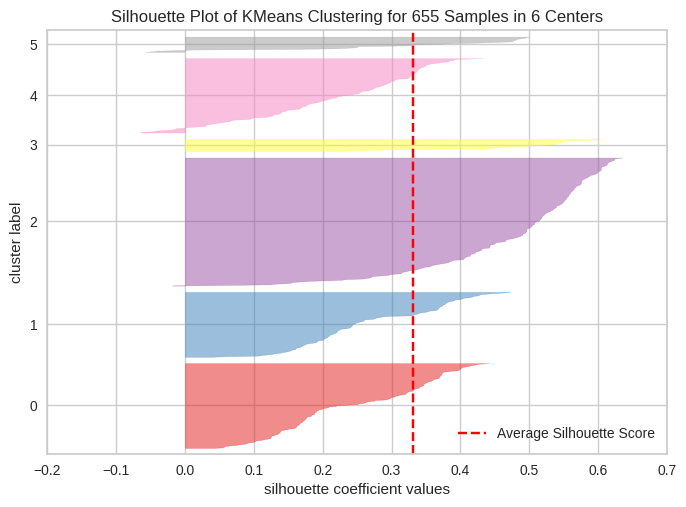

In [ ]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state = 1))
visualizer.fit(subset_scaled_df)
visualizer.show();

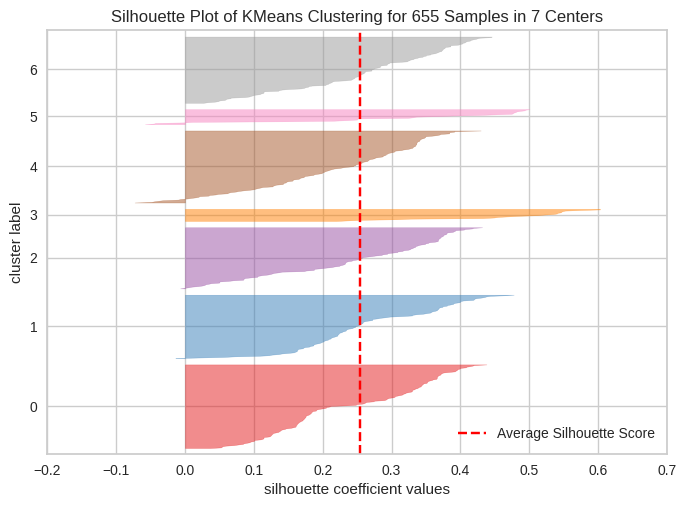

In [ ]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(7, random_state = 1))
visualizer.fit(subset_scaled_df)
visualizer.show();

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=3, random_state=0)

In [ ]:
CreditCardData['K_means_segments'] = kmeans.labels_
subset_scaled_df['K_means_segments'] = kmeans.labels_

In [ ]:
cluster_profile = CreditCardData.iloc[:,1:].groupby('K_means_segments').mean()
cluster_profile['count_in_each_segment'] = CreditCardData.groupby('K_means_segments')['Total_Credit_Cards'].count().values
cluster_profile.style.highlight_max(color = 'lightgreen', axis = 0)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
K_means_segments,,,,,,
0,33604.712042,5.505236,3.494764,0.976440,2.005236,382
1,102612.244898,8.775510,0.591837,10.979592,1.102041,49
2,12174.107143,2.410714,0.933036,3.553571,6.870536,224


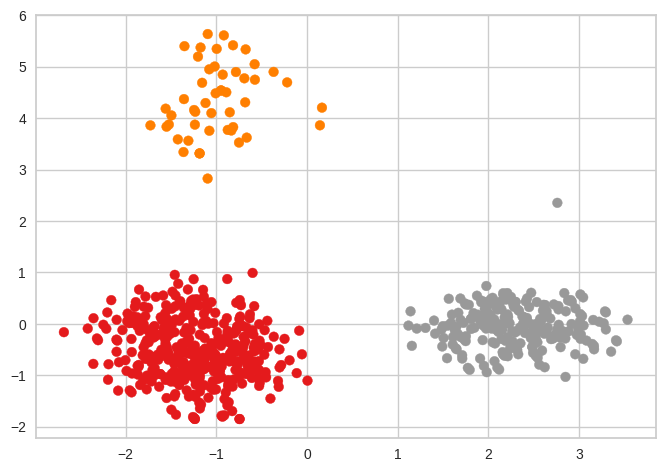

In [ ]:
from sklearn.decomposition import PCA
import pylab as pl
pca=PCA(n_components=3).fit(subset_scaled_df)
pca_2d=pca.transform(subset_scaled_df)
pl.figure("k-means with 3 clusters")
pl.scatter(pca_2d[:,0],pca_2d[:,1],c=kmeans.labels_,cmap='Set1')
pl.show();

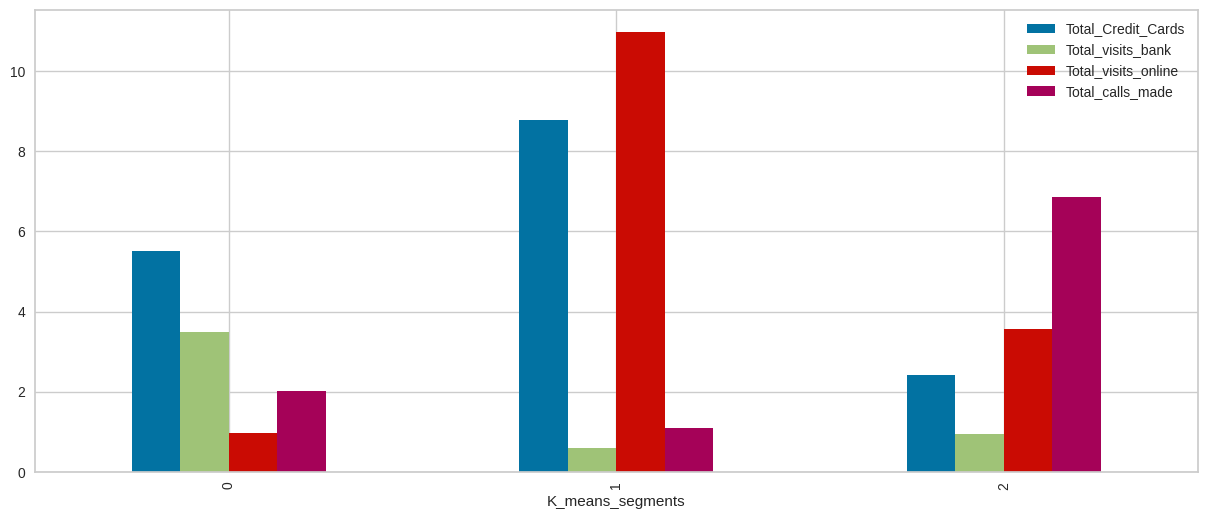

In [ ]:
CreditCardData.iloc[:,2:].groupby('K_means_segments').mean().plot.bar(figsize=(15,6));


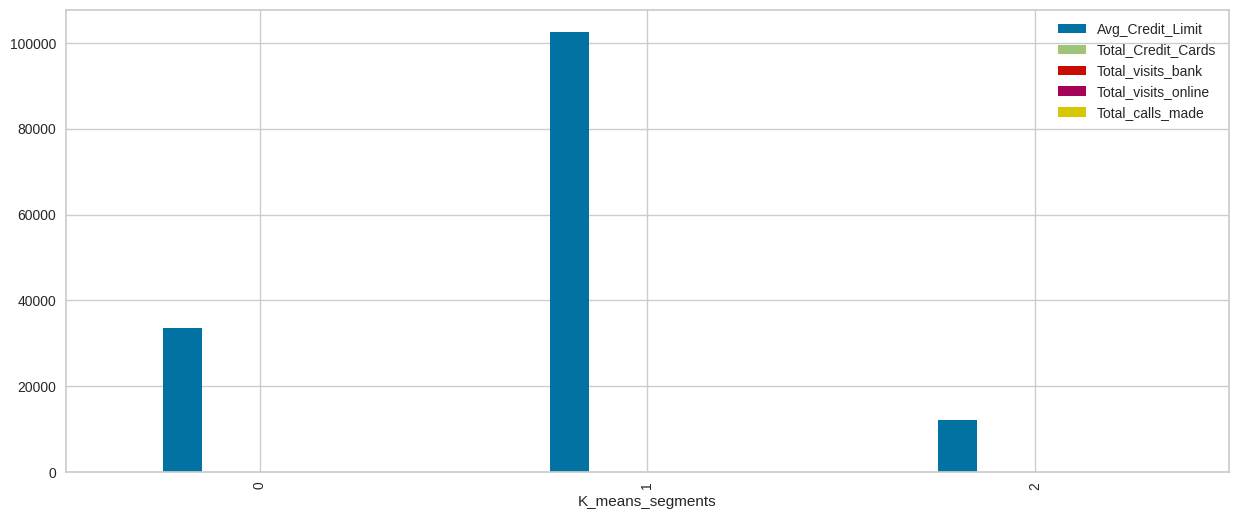

In [ ]:
CreditCardData.iloc[:,1:].groupby('K_means_segments').mean().plot.bar(figsize=(15,6));


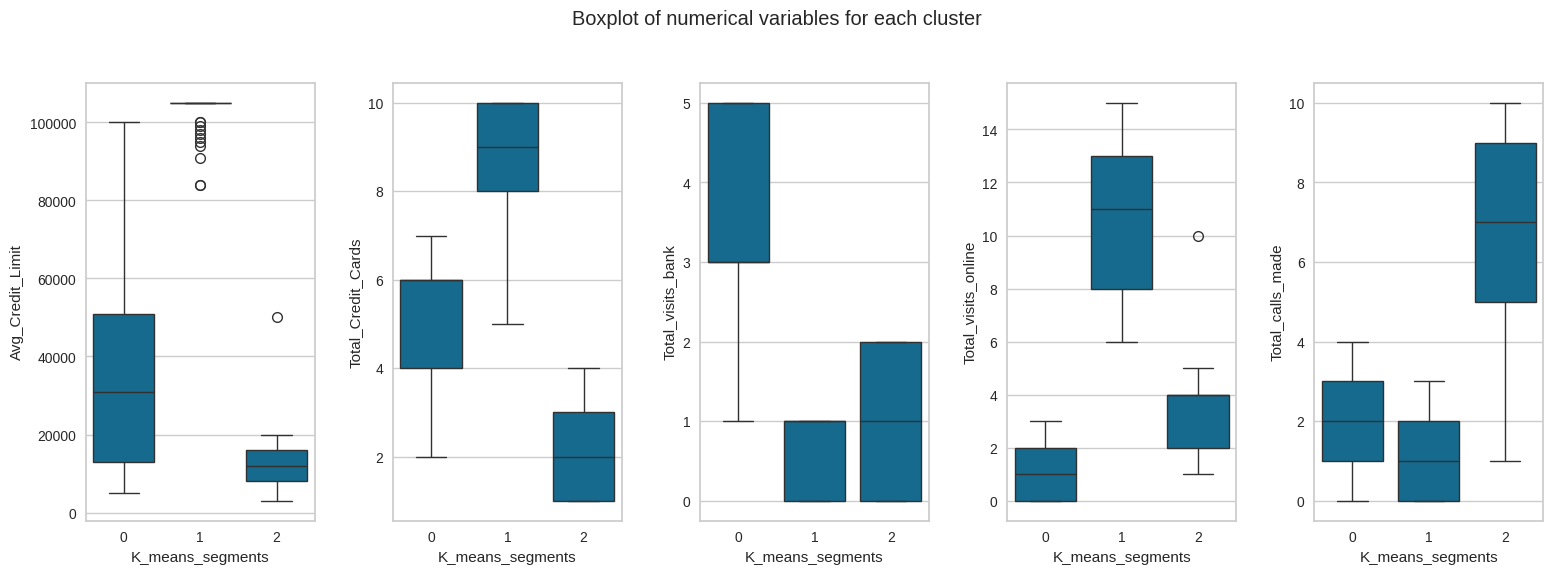

In [ ]:
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster')
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=CreditCardData[all_col[counter]],x=CreditCardData['K_means_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

Compare Cluster vs Total_Credit_Cards

In [ ]:
pd.crosstab(CreditCardData.K_means_segments, CreditCardData.Total_Credit_Cards).style.highlight_max(color = 'lightgreen', axis = 0)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
K_means_segments,,,,,,,,,,
0,0,1,0,102,73,114,92,0,0,0
1,0,0,0,0,1,1,6,11,11,19
2,59,63,53,49,0,0,0,0,0,0


In [ ]:
pd.crosstab(CreditCardData.K_means_segments, CreditCardData.Total_visits_bank).style.highlight_max(color = 'lightgreen', axis = 0)

Total_visits_bank,0,1,2,3,4,5
K_means_segments,,,,,,
0,0,3,91,99,92,97
1,20,29,0,0,0,0
2,80,79,65,0,0,0


In [ ]:
pd.crosstab(CreditCardData.K_means_segments, CreditCardData.Total_visits_online).style.highlight_max(color = 'lightgreen', axis = 0)


Total_visits_online,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
K_means_segments,,,,,,,,,,,,,,,,
0,144,104,133,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,6,6,4,5,5,6,5,1,10
2,0,3,54,43,69,54,0,0,0,0,1,0,0,0,0,0


In [ ]:
pd.crosstab(CreditCardData.K_means_segments, CreditCardData.Total_calls_made).style.highlight_max(color = 'lightgreen', axis = 0)


Total_calls_made,0,1,2,3,4,5,6,7,8,9,10
K_means_segments,,,,,,,,,,,
0,80,74,69,82,77,0,0,0,0,0,0
1,15,15,18,1,0,0,0,0,0,0,0
2,0,1,1,0,31,29,39,35,30,32,26


#Hierarchial Clustering


In [ ]:
subset_scaled_df2 = subset_scaled_df.drop('K_means_segments',axis=1).copy()
CreditCardData=CreditCardData.drop('K_means_segments',axis=1).copy()

In [ ]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering
distance_metrics = [ 'euclidean','chebyshev','mahalanobis','cityblock']
linkage_methods = ['single', 'complete', 'average', 'weighted']
high_cophenet_corr = 0
high_dm_lm = [0,0]
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df2, metric=dm, method=lm)
        c, coph_dists = cophenet(Z , pdist(subset_scaled_df2))
        print('Cophent correlation for distance metrics {} and linkage method {} is {}'.format(dm,lm,c))
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm


Cophent correlation for distance metrics euclidean and linkage method single is 0.705359467615623
Cophent correlation for distance metrics euclidean and linkage method complete is 0.8668293924257054
Cophent correlation for distance metrics euclidean and linkage method average is 0.8902858447098364
Cophent correlation for distance metrics euclidean and linkage method weighted is 0.8753252634903654
Cophent correlation for distance metrics chebyshev and linkage method single is 0.7219778923794835
Cophent correlation for distance metrics chebyshev and linkage method complete is 0.8388571033820141
Cophent correlation for distance metrics chebyshev and linkage method average is 0.8878999292279559
Cophent correlation for distance metrics chebyshev and linkage method weighted is 0.8189672840833921
Cophent correlation for distance metrics mahalanobis and linkage method single is 0.6770235743969137
Cophent correlation for distance metrics mahalanobis and linkage method complete is 0.600699369380

In [ ]:
print('Highest cophenet correlation is {}, which is obtained with {} distance metric and {} linkage method'.format(high_cophenet_corr ,high_dm_lm[0],high_dm_lm[1]))


Highest cophenet correlation is 0.8902858447098364, which is obtained with euclidean distance metric and average linkage method


In [ ]:
linkage_methods = ['single', 'complete', 'average','median','ward', 'weighted']
high_cophenet_corr = 0
high_dm_lm = [0,0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df2, metric='euclidean', method=lm)
    c, coph_dists = cophenet(Z , pdist(subset_scaled_df2))
    print('Cophent correlation for distance metrics {} and linkage method {} is {}'.format('euclidean',lm,c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = 'euclidean'
        high_dm_lm[1] = lm
print('*'*110)
print('Highest cophenet correlation is {}, which is obtinaed with {} distance metric and {} linkage method'.format(high_cophenet_corr ,high_dm_lm[0],high_dm_lm[1]))


Cophent correlation for distance metrics euclidean and linkage method single is 0.705359467615623
Cophent correlation for distance metrics euclidean and linkage method complete is 0.8668293924257054
Cophent correlation for distance metrics euclidean and linkage method average is 0.8902858447098364
Cophent correlation for distance metrics euclidean and linkage method median is 0.8652411270613015
Cophent correlation for distance metrics euclidean and linkage method ward is 0.7433780278360151
Cophent correlation for distance metrics euclidean and linkage method weighted is 0.8753252634903654
**************************************************************************************************************
Highest cophenet correlation is 0.8902858447098364, which is obtinaed with euclidean distance metric and average linkage method


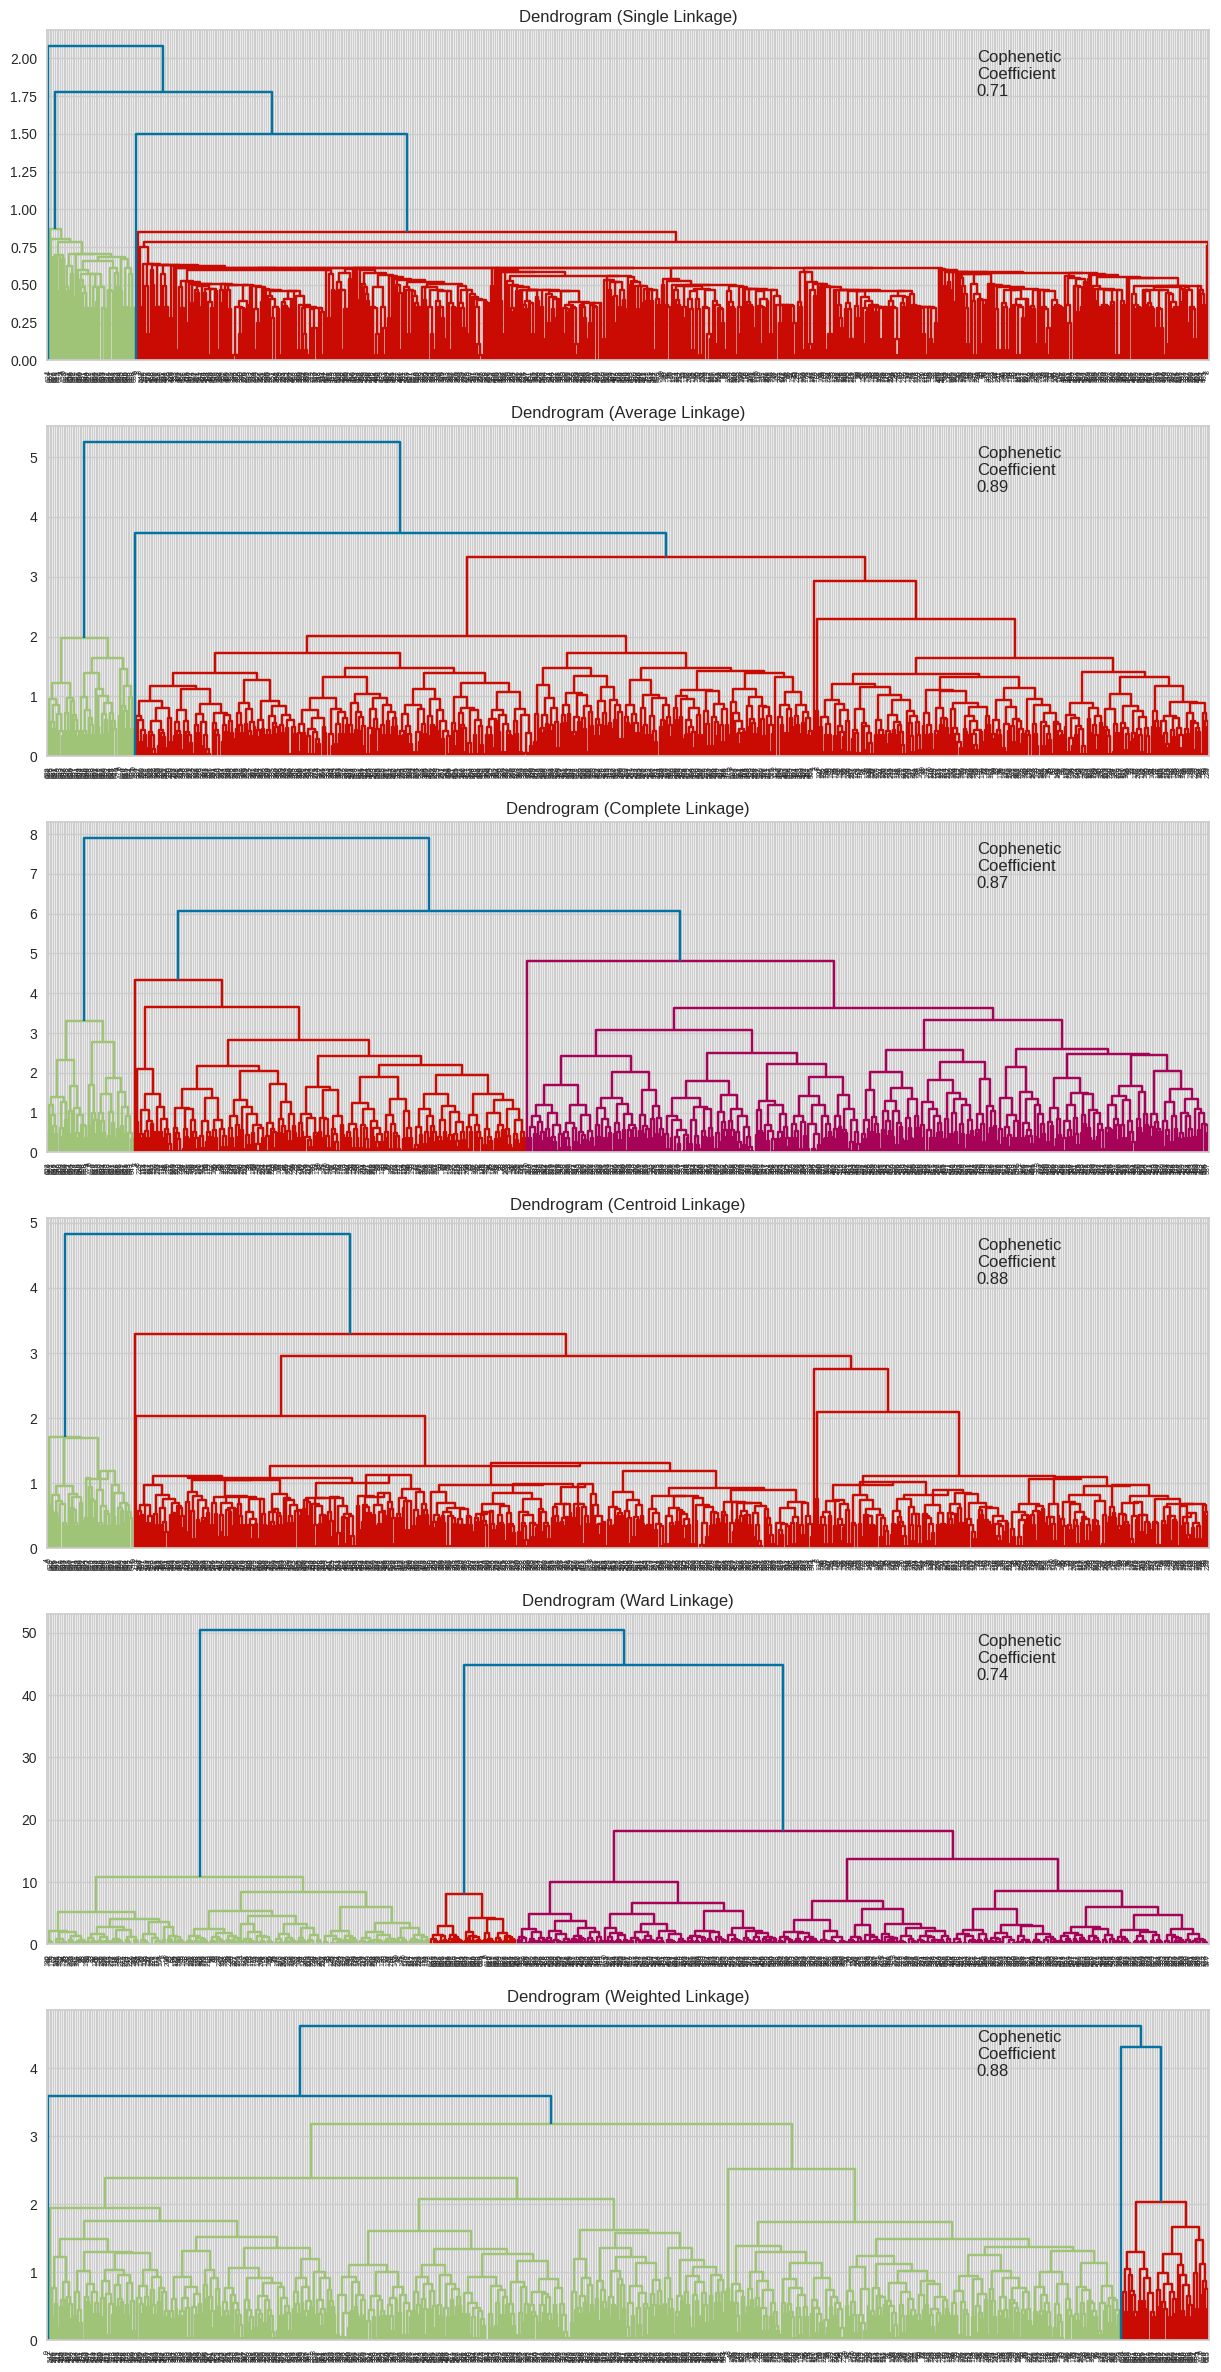

In [ ]:
# List of all linkage methods to check
methods = ['single',
           'average',
           'complete',
           'centroid',
           'ward',
          'weighted']

# Calculate the pairwise distance form the dataset to be used in the cophenetic correlation calculation

# Create lists to save results of coph calculation
compare_cols = ['Linkage', 'Cophenetic Coefficient']
compare = []

# Create a subplot image
fig, axs = plt.subplots(len(methods), 1, figsize=(15, 30))

# Enumerate through the list of all methods above
# Get linkage, plot dendrogram, calculate cophenetic coefficient
for i, method in enumerate(methods):

    Z = linkage(subset_scaled_df2, metric='euclidean', method=method)

    dendrogram(Z, ax=axs[i]);
    axs[i].set_title(f'Dendrogram ({method.capitalize()} Linkage)')
    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df2))
    axs[i].annotate(f'Cophenetic\nCoefficient\n{coph_corr:0.2f}',
                    (0.80, 0.80),
                    xycoords='axes fraction')
    compare.append([method, coph_corr])


In [ ]:
# Create and print dataframe to compare Cophenetic Coefficient for each linkage
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.705359
1,average,0.890286
2,complete,0.866829
3,centroid,0.884713
4,ward,0.743378
5,weighted,0.875325


In [ ]:
distance_metrics = [ 'mahalanobis','cityblock','chebyshev']
linkage_methods = ['average', 'weighted']

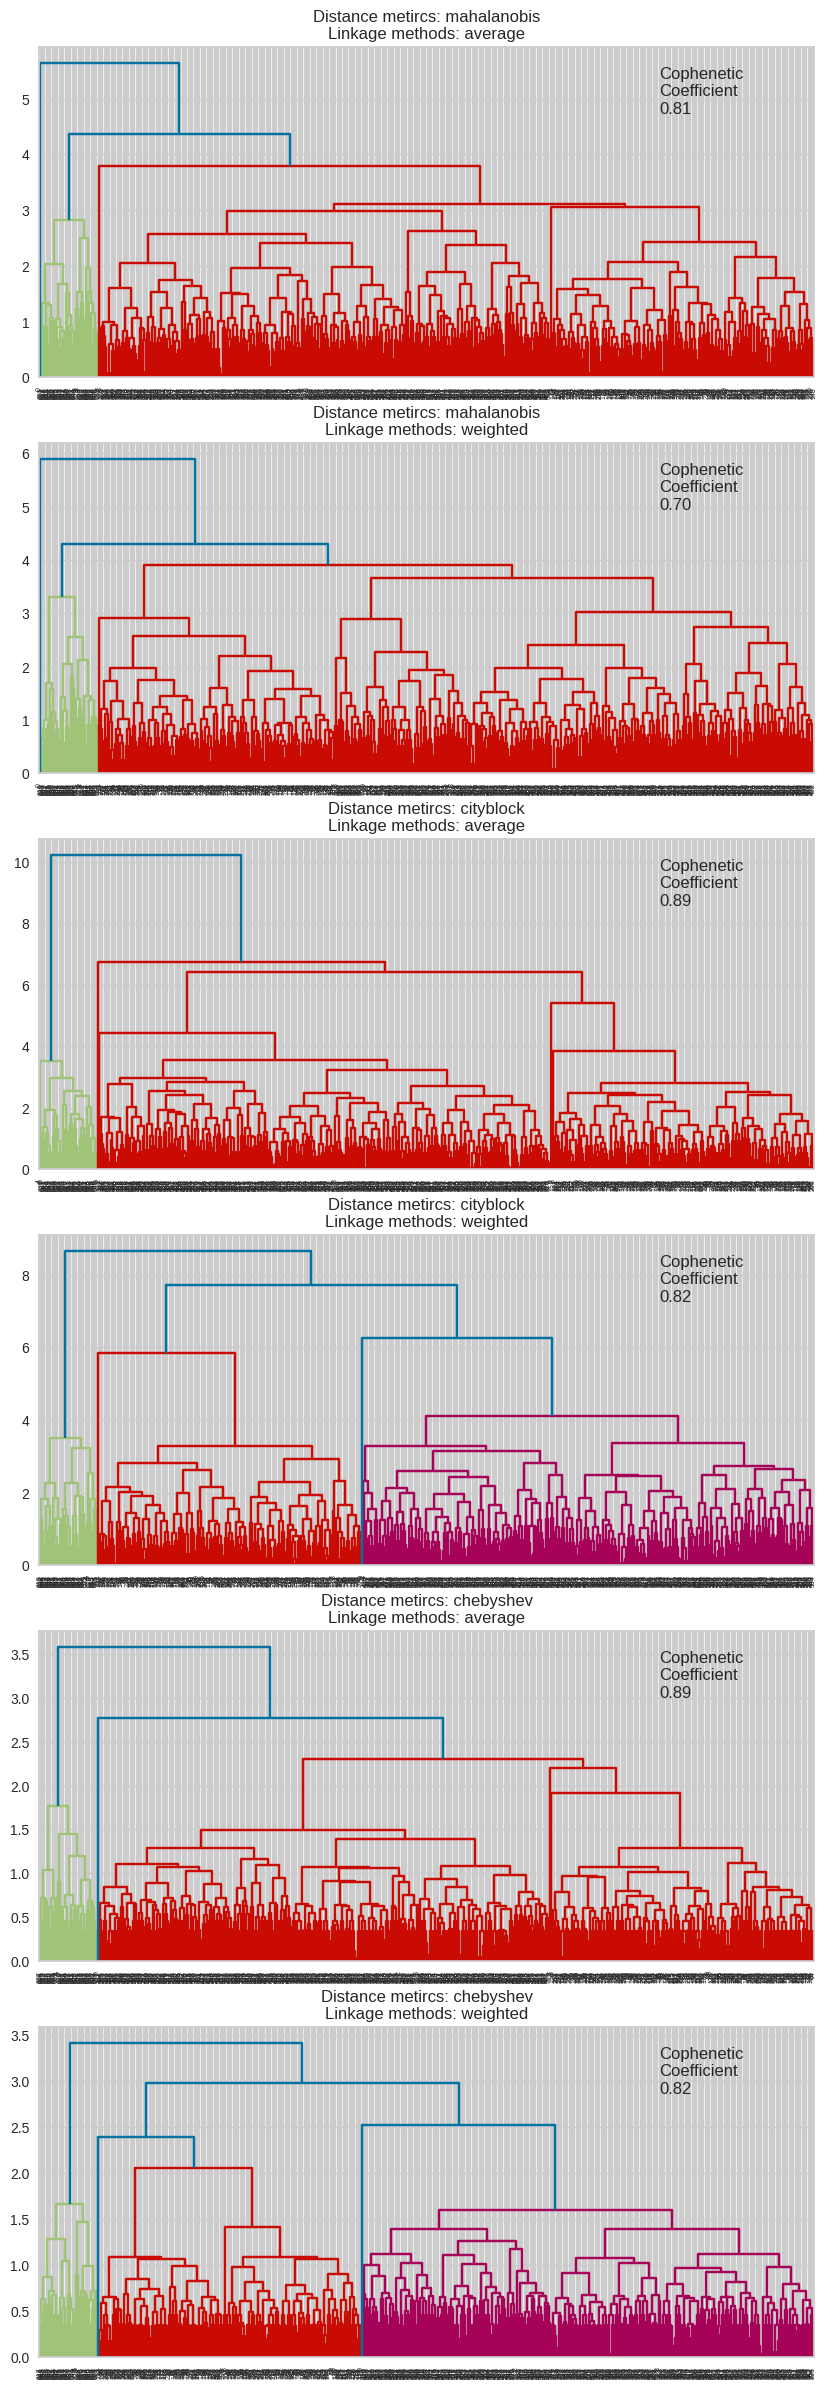

In [ ]:
# Create a subplot image
fig, axs = plt.subplots(len(distance_metrics)+len(distance_metrics), 1, figsize=(10, 30))
i=0
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df2, metric=dm, method=lm)
        dendrogram(Z,  ax=axs[i]);
        axs[i].set_title('Distance metircs: {}\nLinkage methods: {}'.format(dm,lm))
        coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df2))
        axs[i].annotate(f'Cophenetic\nCoefficient\n{coph_corr:0.2f}',
                        (0.80, 0.80),
                        xycoords='axes fraction')
        axs[i].set_title('Distance metircs: {}\nLinkage methods: {}'.format(dm,lm))
        i +=1



In [ ]:
#Trying with 3 clusters
HCmodel = AgglomerativeClustering(n_clusters=3, linkage='single') # Remove affinity argument
HCmodel.fit(subset_scaled_df2)
subset_scaled_df2['HC_Clusters'] = HCmodel.labels_
CreditCardData['HC_Clusters'] = HCmodel.labels_
cluster_profile1 = CreditCardData.iloc[:,1:].groupby('HC_Clusters').mean()
cluster_profile1['count_in_each_segments'] = CreditCardData.groupby('HC_Clusters')['Total_Credit_Cards'].count().values

In [ ]:
# lets display cluster profile
cluster_profile1.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
HC_Clusters,,,,,,
0,25642.975207,4.363636,2.552066,1.915702,3.795041,605
1,50000.000000,3.000000,0.000000,10.000000,9.000000,1
2,102612.244898,8.775510,0.591837,10.979592,1.102041,49


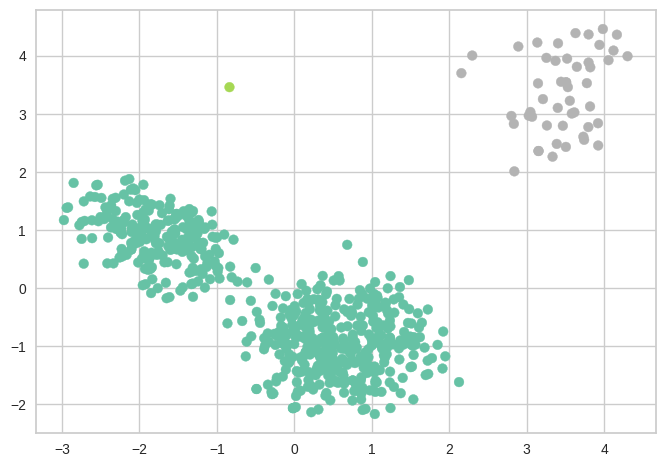

In [ ]:
from sklearn.decomposition import PCA
import pylab as pl
pca=PCA(n_components=3).fit(subset_scaled_df2)
pca_2d=pca.transform(subset_scaled_df2)
pl.figure("HCmodels with 3 clusters")
pl.scatter(pca_2d[:,0],pca_2d[:,1],c=HCmodel.labels_,cmap='Set2')
pl.show();

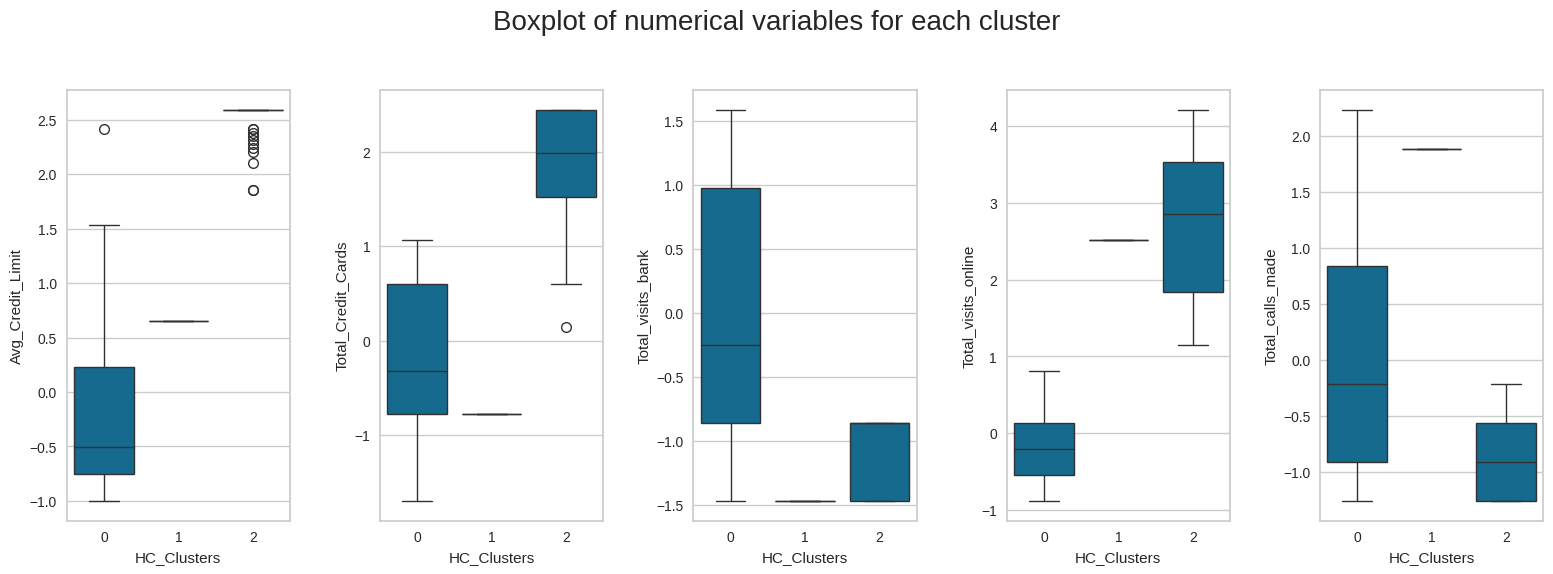

In [ ]:
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=subset_scaled_df2[all_col[counter]],x=subset_scaled_df2['HC_Clusters'])
    counter = counter+1

fig.tight_layout(pad=2.0)

In [ ]:
CreditCardData = CreditCardData.drop('HC_Clusters',axis=1).copy()
subset_scaled_df2 = subset_scaled_df2.drop('HC_Clusters',axis=1).copy()

In [ ]:
#Trying with 4 clusters
HCmodel = AgglomerativeClustering(n_clusters=4, linkage='ward')
HCmodel.fit(subset_scaled_df2)
subset_scaled_df2['HC_Clusters'] = HCmodel.labels_
CreditCardData['HC_Clusters'] = HCmodel.labels_
cluster_profile1 = CreditCardData.iloc[:,1:].groupby('HC_Clusters').mean()
cluster_profile1['count_in_each_segments'] = CreditCardData.groupby('HC_Clusters')['Total_Credit_Cards'].count().values

In [ ]:
# lets display cluster profile
cluster_profile1.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
HC_Clusters,,,,,,
0,19086.419753,5.514403,3.625514,1.086420,2.078189,243
1,12152.777778,2.351852,0.893519,3.569444,6.939815,216
2,102612.244898,8.775510,0.591837,10.979592,1.102041,49
3,56469.387755,5.408163,3.197279,0.911565,2.047619,147


In [ ]:
CreditCardData = CreditCardData.drop('HC_Clusters',axis=1).copy()
subset_scaled_df2 = subset_scaled_df2.drop('HC_Clusters',axis=1).copy()

In [ ]:
#Trying with 3 clusters
HCmodel = AgglomerativeClustering(n_clusters=3, linkage='ward')
HCmodel.fit(subset_scaled_df2)
subset_scaled_df2['HC_Clusters'] = HCmodel.labels_

In [ ]:
CreditCardData['HC_Clusters'] = HCmodel.labels_

In [ ]:
cluster_profile = CreditCardData.iloc[:,1:].groupby('HC_Clusters').mean()

In [ ]:
cluster_profile['count_in_each_segments'] = CreditCardData.groupby('HC_Clusters')['Total_Credit_Cards'].count().values

In [ ]:
# lets display cluster profile
cluster_profile.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
HC_Clusters,,,,,,
0,33176.923077,5.474359,3.464103,1.020513,2.066667,390
1,12152.777778,2.351852,0.893519,3.569444,6.939815,216
2,102612.244898,8.775510,0.591837,10.979592,1.102041,49


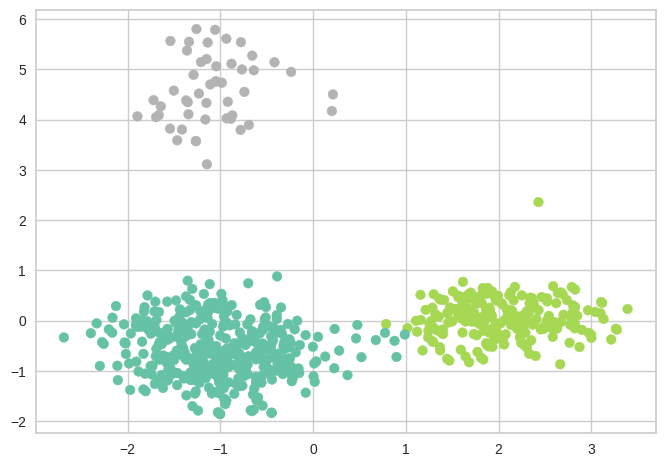

In [ ]:
from sklearn.decomposition import PCA
import pylab as pl
pca=PCA(n_components=3).fit(subset_scaled_df2)
pca_2d=pca.transform(subset_scaled_df2)
pl.figure("HCmodels with 3 clusters")
pl.scatter(pca_2d[:,0],pca_2d[:,1],c=HCmodel.labels_,cmap='Set2')
pl.show();

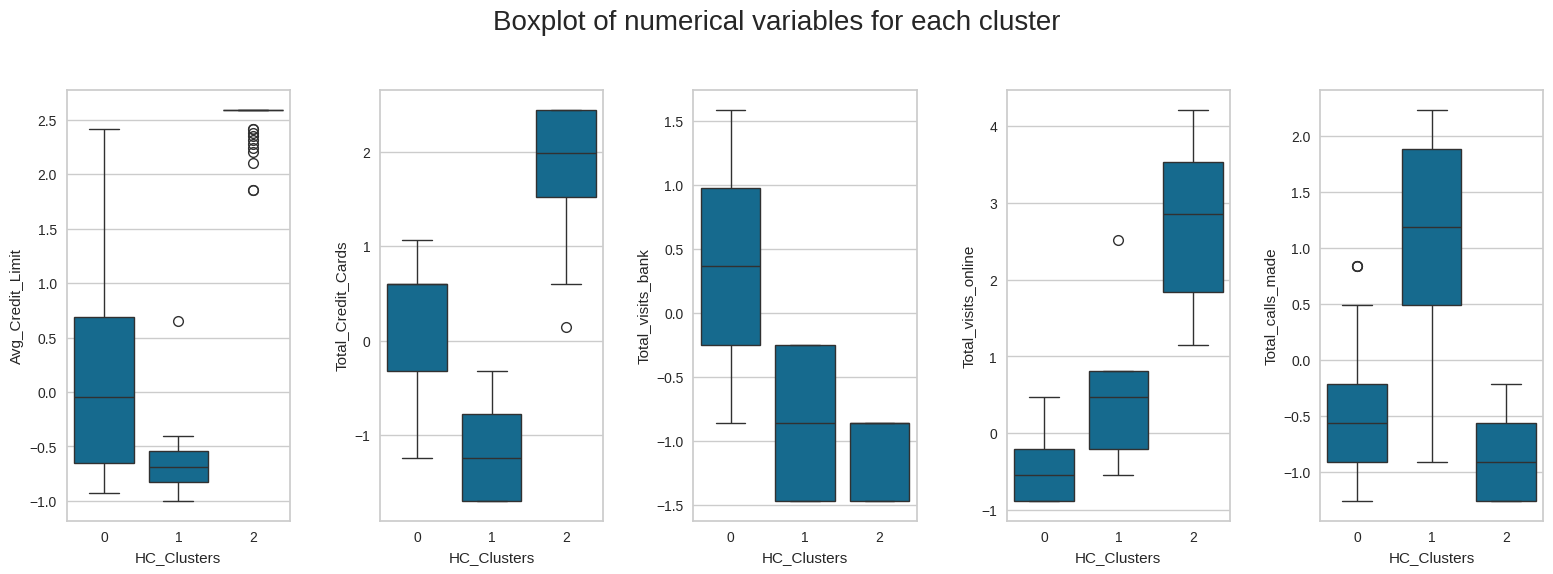

In [ ]:
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=subset_scaled_df2[all_col[counter]],x=subset_scaled_df2['HC_Clusters'])
    counter = counter+1

fig.tight_layout(pad=2.0)

In [ ]:
pd.crosstab(CreditCardData['HC_Clusters'], CreditCardData.Total_Credit_Cards).style.highlight_max(color = 'lightgreen', axis = 0)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
HC_Clusters,,,,,,,,,,
0,0,1,0,110,73,114,92,0,0,0
1,59,63,53,41,0,0,0,0,0,0
2,0,0,0,0,1,1,6,11,11,19


In [ ]:
pd.crosstab(CreditCardData['HC_Clusters'], CreditCardData.Total_Credit_Cards).style.highlight_max(color = 'lightgreen', axis = 0)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
HC_Clusters,,,,,,,,,,
0,0,1,0,110,73,114,92,0,0,0
1,59,63,53,41,0,0,0,0,0,0
2,0,0,0,0,1,1,6,11,11,19


#PCA
##Bartletts Test of Sphericity

In [ ]:
!pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(CreditCardData)
p_value

0.0

### KMO Test
It used to check for sample adequecy before proceeding with PCA

KMO of greater than 0.5 indicates that sample size is adequate for getting the components

In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(CreditCardData)
kmo_model

0.7093127038207405

In [ ]:
subset_scaled_df3 = subset_scaled_df2.drop('HC_Clusters',axis=1).copy()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(subset_scaled_df3)

PCA()

In [ ]:
# Show variance explained by individual components
pca.explained_variance_ratio_

array([0.46564403, 0.35223138, 0.06517441, 0.06239912, 0.05455106])

Text(0, 0.5, 'Cumulative Explained Variance')

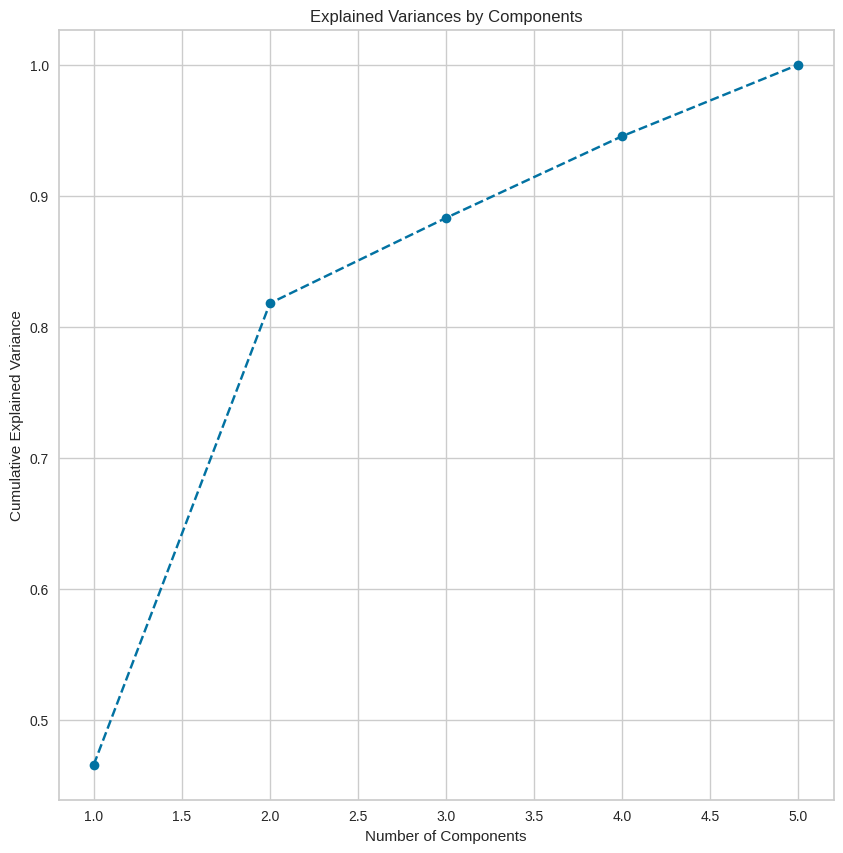

In [ ]:
# visulaize the Explained Individual Components
plt.figure(figsize = (10,10))
plt.plot(range(1,6), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title("Explained Variances by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

In [ ]:
pca = PCA(.9,svd_solver ='full') # svd_solver -full helps to converge faster in case of very large data set
pca.fit(subset_scaled_df3)

PCA(n_components=0.9, svd_solver='full')

In [ ]:
pca.explained_variance_

array([2.3317801 , 1.76384978, 0.32637034, 0.31247268])

Text(0, 0.5, 'Cumulative Explained Variance')

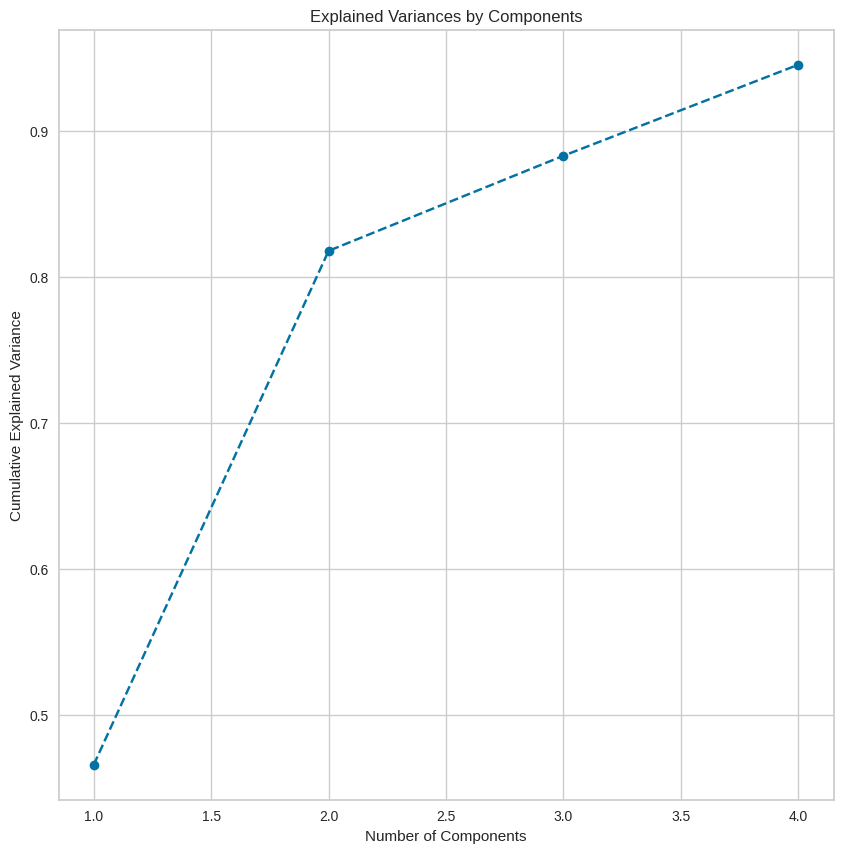

In [ ]:
plt.figure(figsize = (10,10))
plt.plot(range(1,5), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title("Explained Variances by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

In [ ]:
subset_pca = pca.transform(subset_scaled_df3)
subset_pca = pd.DataFrame(subset_pca)

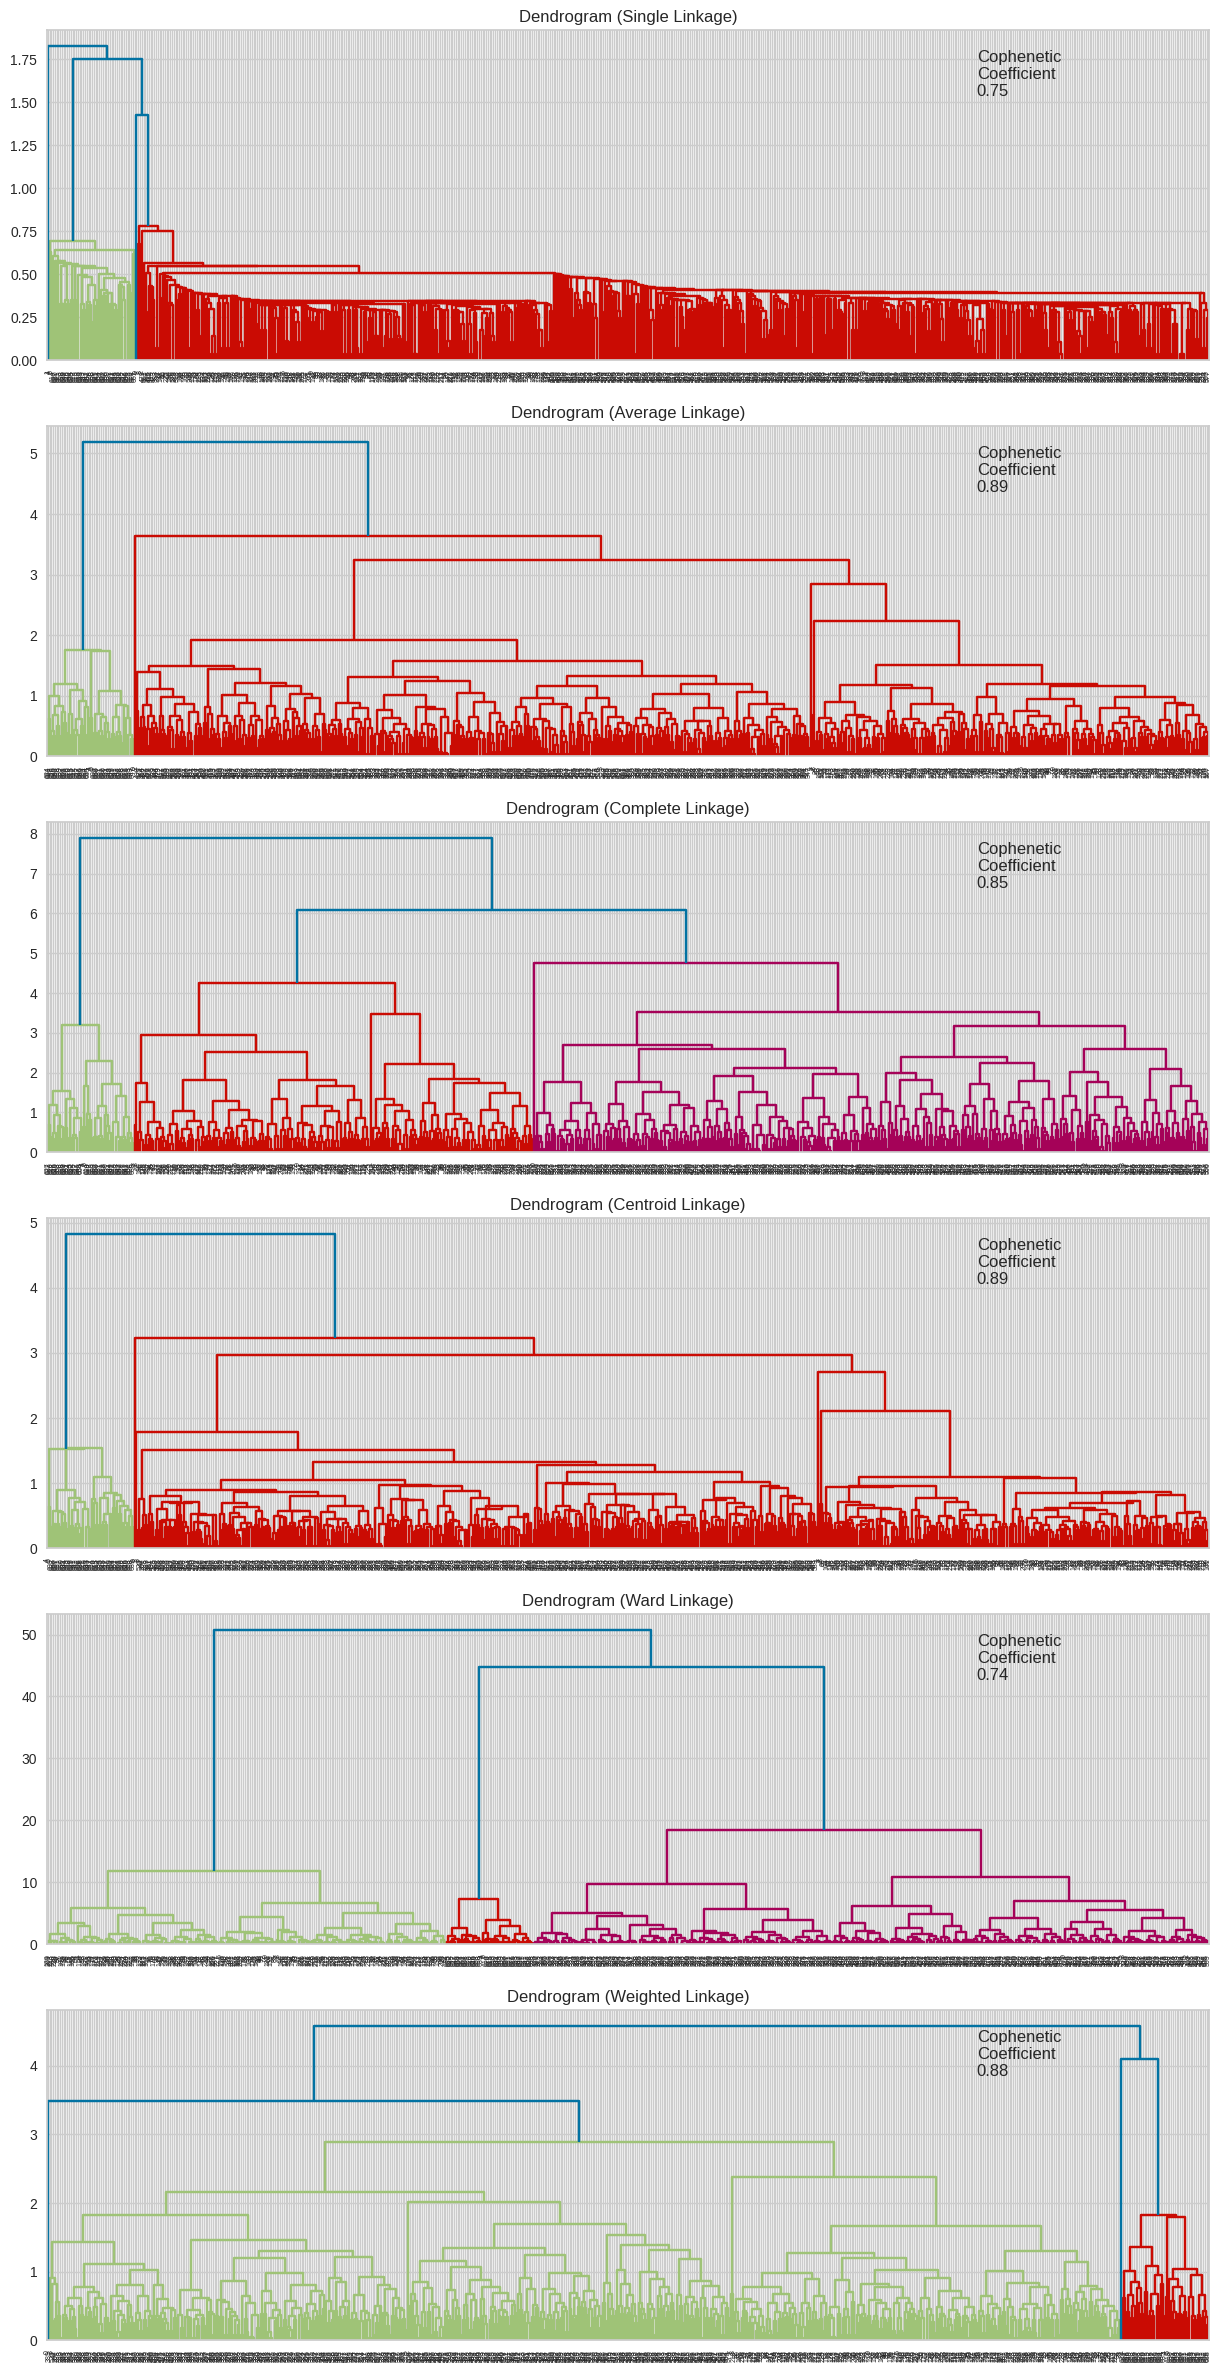

In [ ]:
# List of all linkage methods to check
methods = ['single',
           'average',
           'complete',
           'centroid',
           'ward',
          'weighted']

# Calculate the pairwise distance form the dataset to be used in the cophenetic correlation calculation
#pw_distance = pdist(credit_scaled)

# Create lists to save results of coph calculation
compare_cols = ['Linkage', 'Cophenetic Coefficient']
# compare = []

# Create a subplot image
fig, axs = plt.subplots(len(methods), 1, figsize=(15, 30))

# Enumerate through the list of all methods above
# Get linkage, plot dendrogram, calculate cophenetic coefficient
for i, method in enumerate(methods):

    Z = linkage(subset_pca, metric='euclidean', method=method)

    dendrogram(Z, ax=axs[i]);
    axs[i].set_title(f'Dendrogram ({method.capitalize()} Linkage)')
    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df3))
    axs[i].annotate(f'Cophenetic\nCoefficient\n{coph_corr:0.2f}',
                    (0.80, 0.80),
                    xycoords='axes fraction')
#     compare.append([method, coph_corr])


In [ ]:
hc = AgglomerativeClustering(n_clusters = 3,  linkage = 'ward')
hc_labels = hc.fit_predict(subset_pca)

In [ ]:
CreditCardData['PCA_HC_clusters'] = hc_labels

In [ ]:
cluster_profile2 = CreditCardData.iloc[:,1:].groupby('PCA_HC_clusters').mean()
cluster_profile2['count_in_each_segments'] = CreditCardData.groupby('PCA_HC_clusters')['Total_Credit_Cards'].count().values

In [ ]:
# lets see names of countries in each cluster
for cl in CreditCardData['PCA_HC_clusters'].unique():

    print(CreditCardData[CreditCardData['PCA_HC_clusters']==cl]['Total_Credit_Cards'].unique())

[2 7 5 4 6]
[3 2 4 1 5]
[ 6  5  9  8 10  7]


In [1]:
# lets display cluster profile
cluster_profile2.style.highlight_max(color = 'lightgreen', axis = 0)


NameError: name 'cluster_profile2' is not defined